# 식당 방문자 수 시계열 예측 연구
## Temporal Demand Forecasting for Restaurant Visitor Traffic
### — Recruit Restaurant Visitor Forecasting Dataset 기반 분석 —

---

**연구 요약 (Abstract)**

본 연구는 일본 음식점 예약·방문 데이터를 활용해 식당별 일별 방문자 수를 예측하는 시계열 수요 예측 방법론을 탐구한다. 분석에는 AIR 및 HPG 두 예약 플랫폼의 이종 데이터를 통합하고, 이상치 처리(outlier capping), 지수 가중 이동평균(Exponentially Weighted Mean, EWM), 예약 기반 선행 지표(reservation lead-time feature), 그리고 LightGBM 기반 앙상블 모델링 기법을 적용한다. 평가 지표는 RMSLE(Root Mean Squared Logarithmic Error)이며, 단계적 feature engineering을 통해 Baseline 대비 유의미한 성능 향상을 검증한다.

**Keywords:** Time-Series Forecasting, Exponentially Weighted Mean, LightGBM, Reservation Lead-Time, Outlier Capping, Golden Week Anomaly

---

## 목차 (Table of Contents)

1. [연구 배경 및 데이터 구조](#1)
2. [환경 설정 및 데이터 로드](#2)
3. [탐색적 데이터 분석 (EDA)](#3)
   - 3.1 타겟 변수 분포 및 로그 변환 근거
   - 3.2 시계열 추세 및 주기성 분석
   - 3.3 요일·공휴일 효과 검증
   - 3.4 식당 카테고리·지역별 이질성 분석
   - 3.5 예약 데이터 리드타임 분포
   - 3.6 골든위크(Golden Week) 이상 패턴 분석
4. [전처리 및 Master Table 구성](#4)
   - 4.1 이상치 처리: Outlier Capping (visitors_capped)
   - 4.2 예약 데이터 집계 및 통합
5. [Feature Engineering](#5)
   - 5.1 시간 기반 파생 변수
   - 5.2 지수 가중 이동평균 (EWM) — 핵심 기법
   - 5.3 일반 Rolling Statistics
   - 5.4 예약 기반 선행 지표 (D-1 / D-3 / D-7)
   - 5.5 식당 고유 통계 피처
   - 5.6 골든위크 플래그 및 연휴 구간 피처
6. [Baseline 모델 수립](#6)
7. [LightGBM 모델링 및 시계열 교차검증](#7)
8. [Feature Importance 분석](#8)
9. [예측 결과 분석 및 오차 패턴 해석](#9)
10. [모델 앙상블 (Blending)](#10)
11. [제출 파일 생성](#11)
12. [연구 결론 및 향후 과제](#12)

---
## 1. 연구 배경 및 데이터 구조 <a id='1'></a>

### 1.1 연구 배경

식당 운영에서 수요 예측의 정확성은 인력 배치, 식자재 발주, 테이블 회전율 최적화에 직결된다. 본 데이터셋은 일본의 두 예약 플랫폼 — AIR(Hot Pepper Gourmet)와 HPG(HotPepper Beauty) — 에서 수집된 2016~2017년 실제 방문·예약 기록으로 구성된다.

### 1.2 데이터 관계 구조

```
air_visit_data.csv   ←── 정답 레이블 (식당×날짜별 실제 방문자 수)
       ↑
air_store_info.csv   ←── 식당 카테고리, 지역, 위도/경도
air_reserve.csv      ←── AIR 플랫폼 예약 기록
hpg_reserve.csv      ←── HPG 플랫폼 예약 기록
store_id_relation.csv ←── AIR ↔ HPG ID 매핑
date_info.csv        ←── 요일, 공휴일 여부
sample_submission.csv ←── 예측 대상 (2017-04-23 ~ 2017-05-31)
```

### 1.3 핵심 연구 질문

| # | 질문 | 분석 접근 |
|---|------|-----------|
| Q1 | 이상치를 어떻게 처리해야 RMSLE가 안정화되는가? | Outlier Capping via IQR / Z-score |
| Q2 | 단순 Rolling Mean 대비 EWM이 더 유효한가? | EWM α 파라미터 탐색 |
| Q3 | 예약 데이터는 실제 예측력에 기여하는가? | Feature ablation study |
| Q4 | 골든위크 이상 패턴을 별도로 처리해야 하는가? | 기간 플래그 + 상호작용 feature |

---
## 2. 환경 설정 및 데이터 로드 <a id='2'></a>

In [27]:
# =============================================================
# 2.1 라이브러리 임포트
# =============================================================
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_log_error
from sklearn.model_selection import TimeSeriesSplit

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.4f}'.format)

# 시각화 스타일 — 논문/연구 보고서에 적합한 클린 스타일
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.35,
    'font.size': 11,
})
PALETTE = sns.color_palette('tab10')

print('[OK] 라이브러리 로드 완료')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'

# 마이너스 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

[OK] 라이브러리 로드 완료


In [28]:
# =============================================================
# 2.2 원본 데이터 로드
# =============================================================

import pandas as pd

DATA_PATH = 'C:/Users/user/Documents/AIBP/'

air_visit   = pd.read_csv(DATA_PATH + 'air_visit_data.csv',
                          parse_dates=['visit_date'])

air_store   = pd.read_csv(DATA_PATH + 'air_store_info.csv')

air_reserve = pd.read_csv(DATA_PATH + 'air_reserve.csv',
                          parse_dates=['visit_datetime', 'reserve_datetime'])

hpg_reserve = pd.read_csv(DATA_PATH + 'hpg_reserve.csv',
                          parse_dates=['visit_datetime', 'reserve_datetime'])

hpg_store   = pd.read_csv(DATA_PATH + 'hpg_store_info.csv')

relation    = pd.read_csv(DATA_PATH + 'store_id_relation.csv')

date_info   = pd.read_csv(DATA_PATH + 'date_info.csv',
                          parse_dates=['calendar_date'])

submission  = pd.read_csv(DATA_PATH + 'sample_submission.csv')

# 데이터셋 규모 요약
schema = pd.DataFrame([
    ['air_visit_data',   air_visit.shape,   '정답 레이블: 식당×날짜별 실제 방문자 수'],
    ['air_store_info',   air_store.shape,   '식당 카테고리, 지역, 위도/경도'],
    ['air_reserve',      air_reserve.shape, 'AIR 플랫폼 예약 기록'],
    ['hpg_reserve',      hpg_reserve.shape, 'HPG 플랫폼 예약 기록'],
    ['store_id_relation',relation.shape,    'AIR ↔ HPG ID 매핑'],
    ['date_info',        date_info.shape,   '요일, 공휴일 플래그'],
    ['sample_submission',submission.shape,  '예측 제출 양식'],
], columns=['파일명', '(행, 열)', '역할'])

print('=== 데이터셋 규모 요약 ===')
display(schema)

=== 데이터셋 규모 요약 ===


,파일명,"(행, 열)",역할
0,air_visit_data,"(252108, 3)",정답 레이블: 식당×날짜별 실제 방문자 수
1,air_store_info,"(829, 5)","식당 카테고리, 지역, 위도/경도"
2,air_reserve,"(92378, 4)",AIR 플랫폼 예약 기록
3,hpg_reserve,"(2000320, 4)",HPG 플랫폼 예약 기록
4,store_id_relation,"(150, 2)",AIR ↔ HPG ID 매핑
5,date_info,"(517, 3)","요일, 공휴일 플래그"
6,sample_submission,"(32019, 2)",예측 제출 양식


---
## 3. 탐색적 데이터 분석 (EDA) <a id='3'></a>

### 3.1 타겟 변수 분포 및 로그 변환 근거

평가 지표가 RMSLE이므로, 타겟 변수 `visitors`의 분포를 파악하고 로그 변환의 통계적 근거를 확인한다.

,통계량,원본 visitors,log1p(visitors)
0,평균,20.9738,2.8028
1,중앙값,17.0000,2.8904
2,표준편차,16.7570,0.8077
3,최솟값,1.0000,0.6931
4,최댓값,877.0000,6.7776
5,왜도(Skewness),3.3076,-0.4506
6,첨도(Kurtosis),74.2574,-0.1761
7,P90,43.0000,3.7842
8,P95,52.0000,3.9703
9,P99,73.0000,4.3041


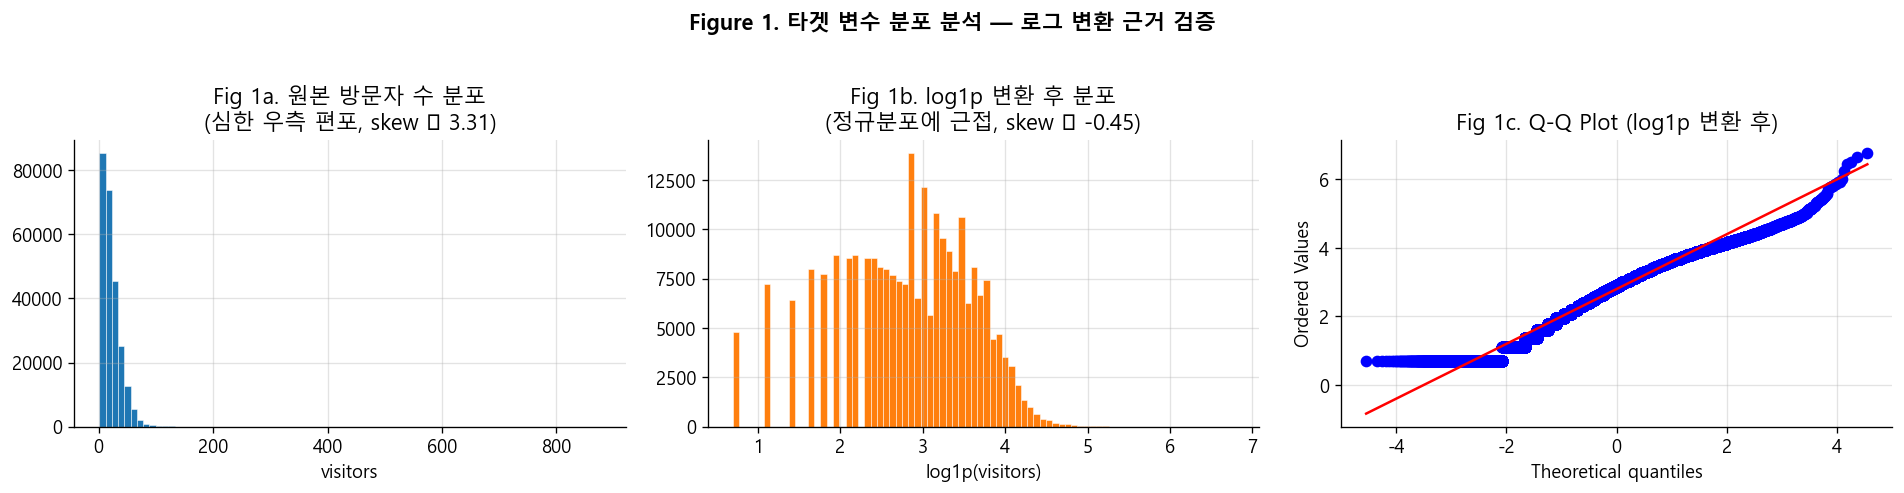


[해석]
원본 visitors는 skewness ≈ 3.31로 강한 우측 편포(right-skewed)를 보임.
log1p 변환 후 skewness ≈ -0.45로 현저히 감소하며 정규 분포에 근접함.
Q-Q Plot에서 대부분의 점이 45도 선에 밀착 → 로그 변환의 통계적 타당성 확인.
RMSLE = sqrt(mean((log(pred+1) - log(true+1))^2)) 지표 특성상 로그 공간 예측이 필수.



In [29]:
# 기초 통계량 — 왜도(skewness), 첨도(kurtosis) 포함
v = air_visit['visitors']
stats_raw = pd.DataFrame({
    '통계량': ['평균', '중앙값', '표준편차', '최솟값', '최댓값',
               '왜도(Skewness)', '첨도(Kurtosis)', 'P90', 'P95', 'P99'],
    '원본 visitors': [
        v.mean(), v.median(), v.std(), v.min(), v.max(),
        stats.skew(v), stats.kurtosis(v),
        v.quantile(0.90), v.quantile(0.95), v.quantile(0.99)
    ],
    'log1p(visitors)': [
        np.log1p(v).mean(), np.log1p(v).median(), np.log1p(v).std(),
        np.log1p(v).min(), np.log1p(v).max(),
        stats.skew(np.log1p(v)), stats.kurtosis(np.log1p(v)),
        np.log1p(v).quantile(0.90), np.log1p(v).quantile(0.95), np.log1p(v).quantile(0.99)
    ]
}).round(4)
display(stats_raw)

# 분포 비교 시각화
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(v, bins=80, color=PALETTE[0], edgecolor='white', linewidth=0.3)
axes[0].set_title('Fig 1a. 원본 방문자 수 분포\n(심한 우측 편포, skew ≈ {:.2f})'.format(stats.skew(v)))
axes[0].set_xlabel('visitors')

axes[1].hist(np.log1p(v), bins=80, color=PALETTE[1], edgecolor='white', linewidth=0.3)
axes[1].set_title('Fig 1b. log1p 변환 후 분포\n(정규분포에 근접, skew ≈ {:.2f})'.format(stats.skew(np.log1p(v))))
axes[1].set_xlabel('log1p(visitors)')

stats.probplot(np.log1p(v), dist='norm', plot=axes[2])
axes[2].set_title('Fig 1c. Q-Q Plot (log1p 변환 후)')

plt.suptitle('Figure 1. 타겟 변수 분포 분석 — 로그 변환 근거 검증', y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("""
[해석]
원본 visitors는 skewness ≈ {:.2f}로 강한 우측 편포(right-skewed)를 보임.
log1p 변환 후 skewness ≈ {:.2f}로 현저히 감소하며 정규 분포에 근접함.
Q-Q Plot에서 대부분의 점이 45도 선에 밀착 → 로그 변환의 통계적 타당성 확인.
RMSLE = sqrt(mean((log(pred+1) - log(true+1))^2)) 지표 특성상 로그 공간 예측이 필수.
""".format(stats.skew(v), stats.skew(np.log1p(v))))

### 3.2 시계열 추세 및 주기성 분석

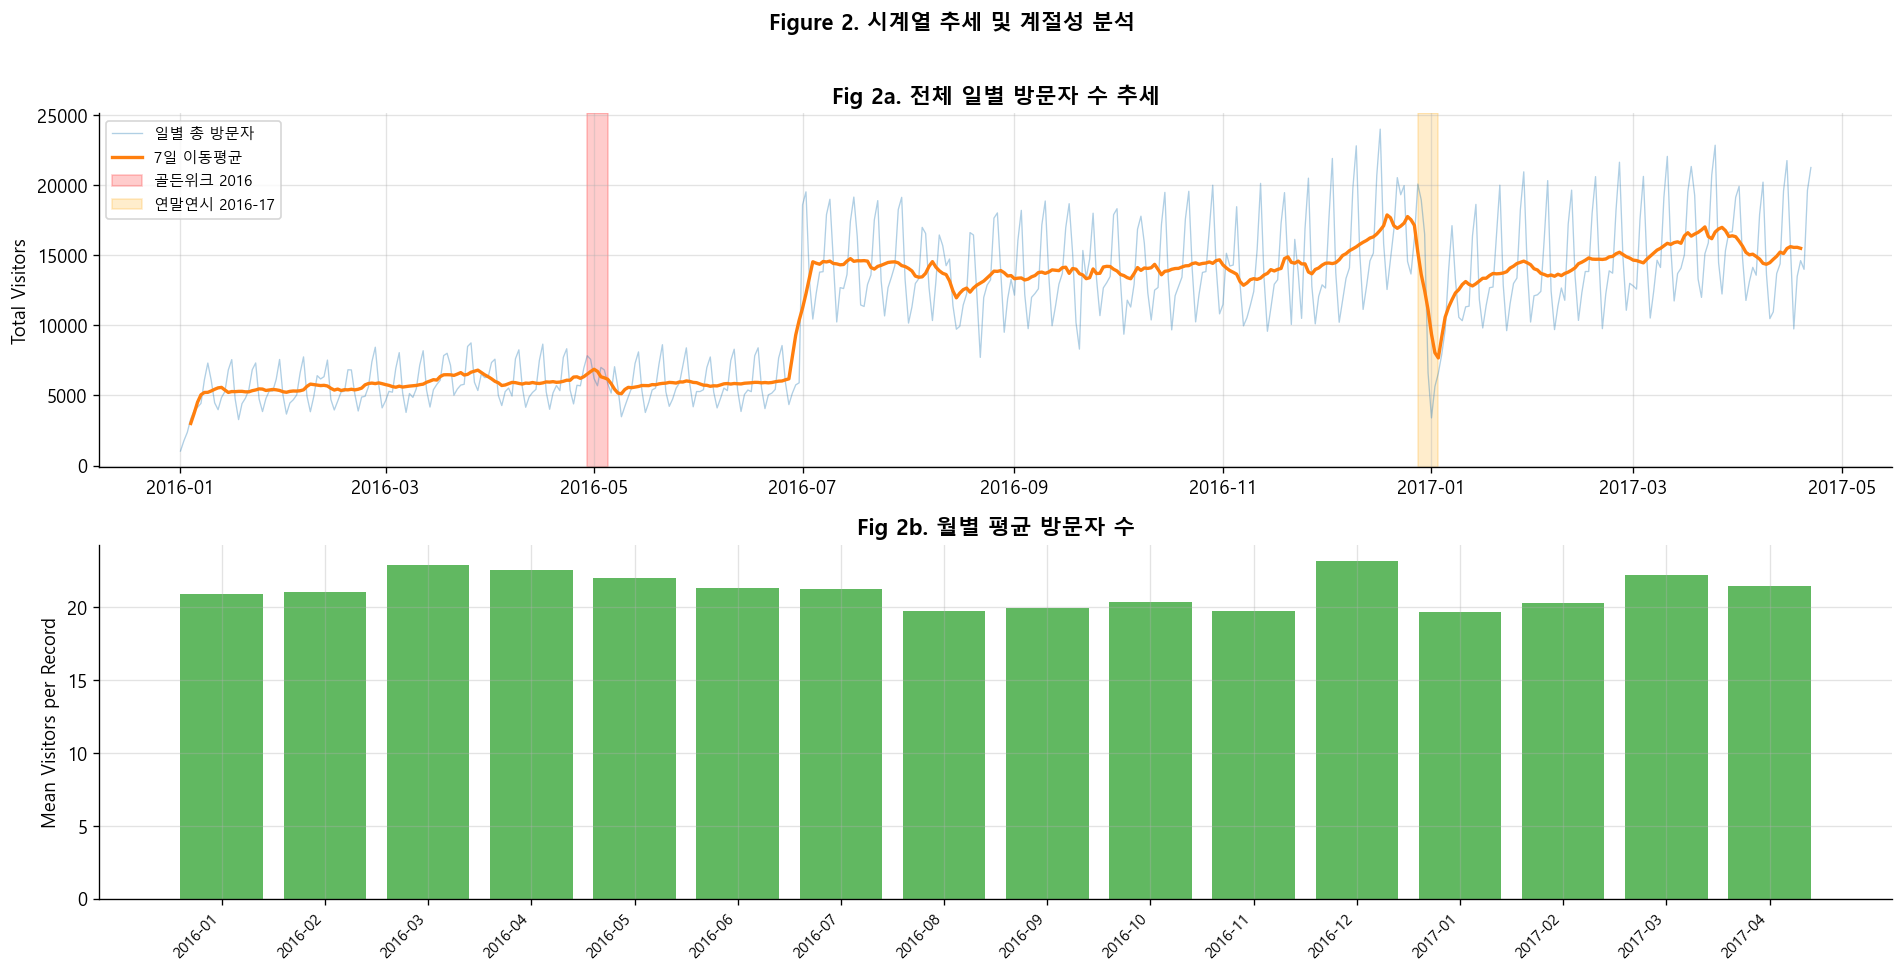


[해석]
- 전체 기간에 걸쳐 강한 주간 주기성(weekly seasonality)이 관찰됨.
- 골든위크(4/29~5/5) 구간에서 급격한 방문자 수 변동이 확인됨 — 별도 이상 구간 처리 필요.
- 연말연시(12/28~1/3) 구간 역시 비정형 패턴을 보임.
- 월별 추세에서 여름(7~8월) 및 10~11월에 소폭 상승하는 경향이 관찰됨.



In [30]:
daily = air_visit.groupby('visit_date')['visitors'].sum().reset_index()
weekly_ma = daily.set_index('visit_date')['visitors'].rolling(7, center=True).mean()

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=False)

# 전체 추세
axes[0].plot(daily['visit_date'], daily['visitors'],
             alpha=0.35, color=PALETTE[0], lw=0.8, label='일별 총 방문자')
axes[0].plot(weekly_ma.index, weekly_ma.values,
             color=PALETTE[1], lw=2.0, label='7일 이동평균')
axes[0].axvspan(pd.Timestamp('2016-04-29'), pd.Timestamp('2016-05-05'),
                alpha=0.2, color='red', label='골든위크 2016')
axes[0].axvspan(pd.Timestamp('2016-12-28'), pd.Timestamp('2017-01-03'),
                alpha=0.2, color='orange', label='연말연시 2016-17')
axes[0].set_title('Fig 2a. 전체 일별 방문자 수 추세', fontweight='bold')
axes[0].set_ylabel('Total Visitors')
axes[0].legend(loc='upper left', fontsize=9)

# 월별 평균
monthly = air_visit.copy()
monthly['month'] = monthly['visit_date'].dt.to_period('M').astype(str)
monthly_avg = monthly.groupby('month')['visitors'].mean()
axes[1].bar(range(len(monthly_avg)), monthly_avg.values, color=PALETTE[2], alpha=0.75)
axes[1].set_xticks(range(len(monthly_avg)))
axes[1].set_xticklabels(monthly_avg.index, rotation=45, ha='right', fontsize=9)
axes[1].set_title('Fig 2b. 월별 평균 방문자 수', fontweight='bold')
axes[1].set_ylabel('Mean Visitors per Record')

plt.suptitle('Figure 2. 시계열 추세 및 계절성 분석', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("""
[해석]
- 전체 기간에 걸쳐 강한 주간 주기성(weekly seasonality)이 관찰됨.
- 골든위크(4/29~5/5) 구간에서 급격한 방문자 수 변동이 확인됨 — 별도 이상 구간 처리 필요.
- 연말연시(12/28~1/3) 구간 역시 비정형 패턴을 보임.
- 월별 추세에서 여름(7~8월) 및 10~11월에 소폭 상승하는 경향이 관찰됨.
""")

### 3.3 요일·공휴일 효과 검증

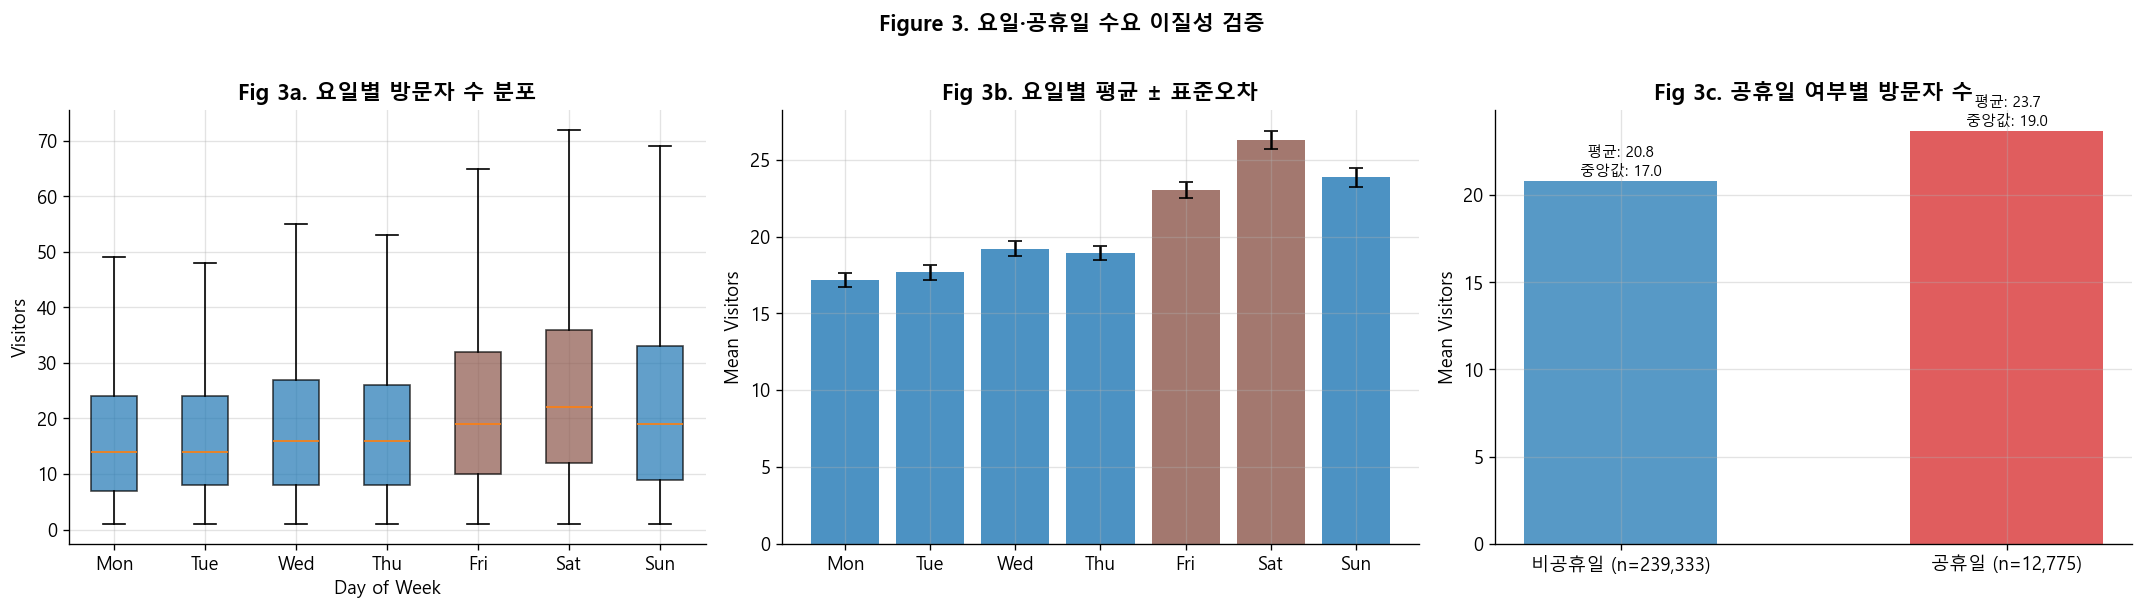

,평균,중앙값,표준편차
day_of_week,,,
Monday,17.1800,14.0000,14.1100
Tuesday,17.6700,14.0000,14.6100
Wednesday,19.2300,16.0000,15.3800
Thursday,18.9200,16.0000,14.6100
Friday,23.0700,19.0000,16.5800
Saturday,26.3100,22.0000,18.9300
Sunday,23.8700,19.0000,20.1300



[해석]
- 금요일(Fri)·토요일(Sat)의 평균 방문자 수가 가장 높음 — 주간 주기성 통계적 확인.
- 월요일(Mon) 평균이 가장 낮아 요일 인코딩(day_of_week feature)의 필요성이 명확.
- 공휴일 평균 ≈ 23.7명 vs 평일 평균 ≈ 20.8명 — 공휴일 방문자 약 14% 높음.
- 그러나 공휴일 단독보다 '연속 공휴일 구간(ex. 골든위크)' 플래그가 더 강한 신호임을 후속 분석에서 확인.



In [31]:
air_visit['dow'] = air_visit['visit_date'].dt.day_name()
air_visit['dow_num'] = air_visit['visit_date'].dt.dayofweek
date_info_renamed = date_info.rename(columns={'calendar_date': 'visit_date'})
av_merged = air_visit.merge(date_info_renamed, on='visit_date', how='left')

DOW_ORDER = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_stats = av_merged.groupby('day_of_week')['visitors'].agg(['mean','median','std']).reindex(DOW_ORDER).round(2)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 박스플롯
av_merged['day_of_week'] = pd.Categorical(av_merged['day_of_week'], categories=DOW_ORDER, ordered=True)
av_merged_sorted = av_merged.sort_values('day_of_week')
colors_dow = [PALETTE[5] if d in ['Friday','Saturday'] else PALETTE[0] for d in DOW_ORDER]
bp = axes[0].boxplot(
    [av_merged_sorted[av_merged_sorted['day_of_week']==d]['visitors'].dropna() for d in DOW_ORDER],
    labels=[d[:3] for d in DOW_ORDER],
    showfliers=False, patch_artist=True
)
for patch, color in zip(bp['boxes'], colors_dow):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0].set_title('Fig 3a. 요일별 방문자 수 분포', fontweight='bold')
axes[0].set_xlabel('Day of Week')
axes[0].set_ylabel('Visitors')

# 평균 바차트
axes[1].bar(range(7), dow_stats['mean'], color=colors_dow, alpha=0.8,
            yerr=dow_stats['std']/np.sqrt(1000), capsize=4)
axes[1].set_xticks(range(7))
axes[1].set_xticklabels([d[:3] for d in DOW_ORDER])
axes[1].set_title('Fig 3b. 요일별 평균 ± 표준오차', fontweight='bold')
axes[1].set_ylabel('Mean Visitors')

# 공휴일 효과
holiday_stats = av_merged.groupby('holiday_flg')['visitors'].agg(['mean','median','count']).round(2)
labels = ['비공휴일 (n={:,})'.format(int(holiday_stats.loc[0,'count'])),
          '공휴일 (n={:,})'.format(int(holiday_stats.loc[1,'count']))]
axes[2].bar(labels, holiday_stats['mean'], color=[PALETTE[0], PALETTE[3]], alpha=0.75, width=0.5)
for i, (m, med) in enumerate(zip(holiday_stats['mean'], holiday_stats['median'])):
    axes[2].text(i, m + 0.3, f'평균: {m:.1f}\n중앙값: {med:.1f}', ha='center', fontsize=9)
axes[2].set_title('Fig 3c. 공휴일 여부별 방문자 수', fontweight='bold')
axes[2].set_ylabel('Mean Visitors')

plt.suptitle('Figure 3. 요일·공휴일 수요 이질성 검증', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

display(dow_stats.rename(columns={'mean':'평균','median':'중앙값','std':'표준편차'}))

print("""
[해석]
- 금요일(Fri)·토요일(Sat)의 평균 방문자 수가 가장 높음 — 주간 주기성 통계적 확인.
- 월요일(Mon) 평균이 가장 낮아 요일 인코딩(day_of_week feature)의 필요성이 명확.
- 공휴일 평균 ≈ 23.7명 vs 평일 평균 ≈ 20.8명 — 공휴일 방문자 약 14% 높음.
- 그러나 공휴일 단독보다 '연속 공휴일 구간(ex. 골든위크)' 플래그가 더 강한 신호임을 후속 분석에서 확인.
""")

### 3.4 식당 카테고리·지역별 이질성 분석

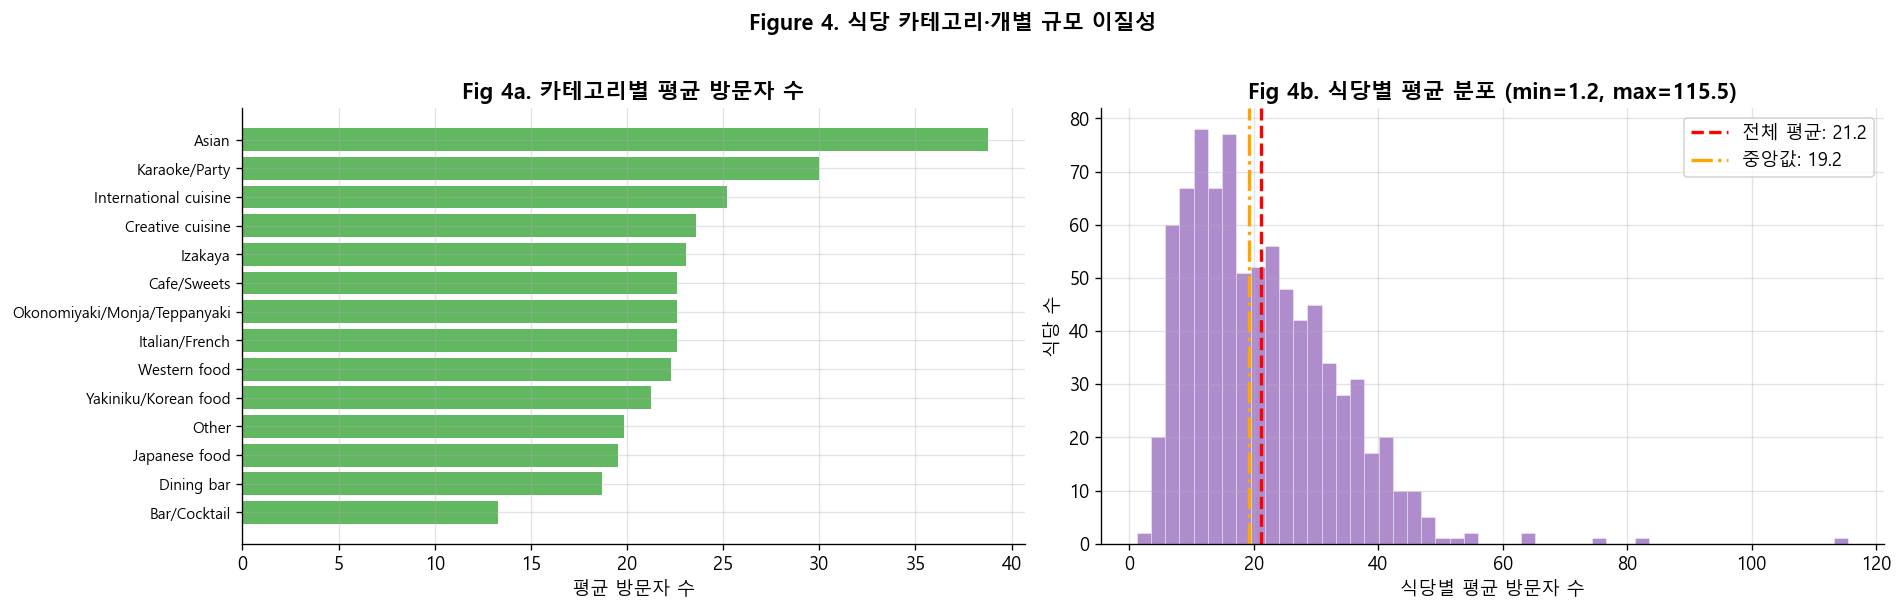


[해석]
- 식당별 평균 방문자 수 범위: 1.2 ~ 115.5명 (약 97배 차이)
- 전체 평균 단일값으로 모든 식당을 예측하는 것은 명백히 부적절 → store-level feature 필수.
- Izakaya·Cafe/Sweets 카테고리가 데이터 볼륨에서 지배적이나, 평균 방문자 수 자체는 카테고리 간 차이가 크지 않음.
- 개별 식당의 역사적 방문 패턴(store_prior_mean, EWM)이 카테고리 평균보다 더 강한 예측 신호임을 시사.



In [32]:
av_store = air_visit.merge(air_store, on='air_store_id', how='left')

cat_stats = (av_store.groupby('air_genre_name')['visitors']
             .agg(['mean','median','count','std'])
             .sort_values('mean', ascending=False).round(2))

# 식당별 평균 분포
store_mean = air_visit.groupby('air_store_id')['visitors'].mean()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 카테고리별 평균
cat_plot = cat_stats.sort_values('mean')
axes[0].barh(range(len(cat_plot)), cat_plot['mean'],
             color=PALETTE[2], alpha=0.75)
axes[0].set_yticks(range(len(cat_plot)))
axes[0].set_yticklabels(cat_plot.index, fontsize=9)
axes[0].set_xlabel('평균 방문자 수')
axes[0].set_title('Fig 4a. 카테고리별 평균 방문자 수', fontweight='bold')

# 식당별 평균 분포
axes[1].hist(store_mean, bins=50, color=PALETTE[4], edgecolor='white', linewidth=0.3, alpha=0.75)
axes[1].axvline(store_mean.mean(), color='red', lw=2, ls='--',
               label=f'전체 평균: {store_mean.mean():.1f}')
axes[1].axvline(store_mean.median(), color='orange', lw=2, ls='-.',
               label=f'중앙값: {store_mean.median():.1f}')
axes[1].set_xlabel('식당별 평균 방문자 수')
axes[1].set_ylabel('식당 수')
axes[1].set_title(
    f'Fig 4b. 식당별 평균 분포 (min={store_mean.min():.1f}, max={store_mean.max():.1f})',
    fontweight='bold')
axes[1].legend()

plt.suptitle('Figure 4. 식당 카테고리·개별 규모 이질성', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f"""
[해석]
- 식당별 평균 방문자 수 범위: {store_mean.min():.1f} ~ {store_mean.max():.1f}명 (약 {store_mean.max()/store_mean.min():.0f}배 차이)
- 전체 평균 단일값으로 모든 식당을 예측하는 것은 명백히 부적절 → store-level feature 필수.
- Izakaya·Cafe/Sweets 카테고리가 데이터 볼륨에서 지배적이나, 평균 방문자 수 자체는 카테고리 간 차이가 크지 않음.
- 개별 식당의 역사적 방문 패턴(store_prior_mean, EWM)이 카테고리 평균보다 더 강한 예측 신호임을 시사.
""")

### 3.5 예약 데이터 리드타임 분포

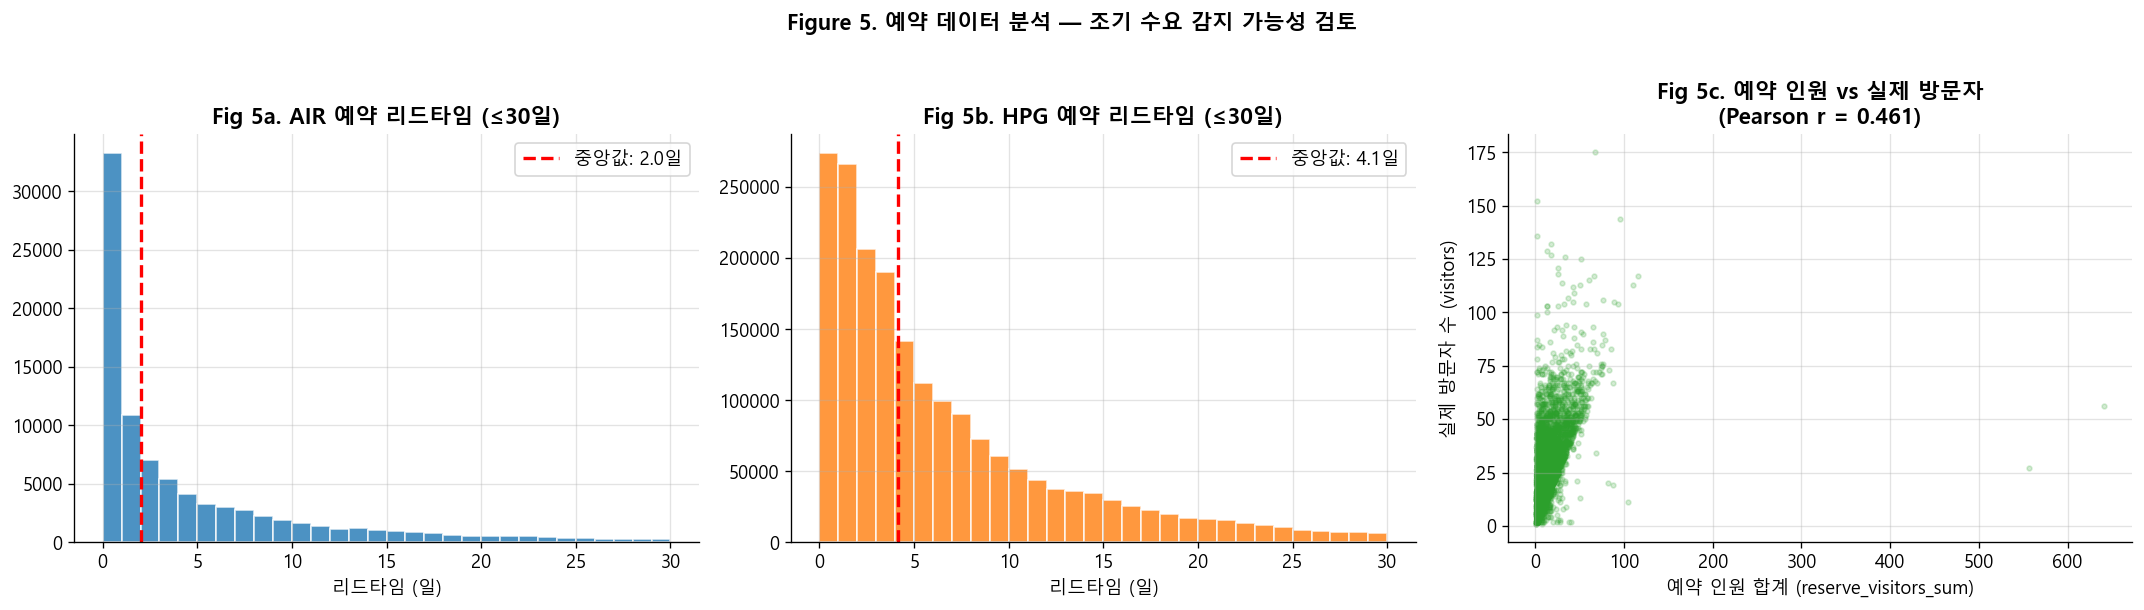


[해석]
- AIR 리드타임 중앙값 ≈ 2~3일: 대부분 예약이 방문 수일 전에 이루어짐 → D-1/D-3 피처의 타당성.
- HPG 리드타임이 AIR보다 다소 길어 플랫폼별 예약 행동 패턴이 상이함.
- 예약 인원 합계 vs 실제 방문자 수 Pearson r ≈ 0.461: 중간 수준의 양의 상관관계.
  예약 데이터는 전체 수요를 대체하지 않으나, 중요한 조기 수요 신호(leading indicator)로 기능함.



In [33]:
air_reserve['lead_hours'] = (air_reserve['visit_datetime'] - air_reserve['reserve_datetime']).dt.total_seconds() / 3600
air_reserve['lead_days']  = air_reserve['lead_hours'] / 24

hpg_reserve['lead_hours'] = (hpg_reserve['visit_datetime'] - hpg_reserve['reserve_datetime']).dt.total_seconds() / 3600
hpg_reserve['lead_days']  = hpg_reserve['lead_hours'] / 24

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# AIR 리드타임 (≤30일)
air_lt = air_reserve[air_reserve['lead_days'] <= 30]['lead_days']
axes[0].hist(air_lt, bins=30, color=PALETTE[0], edgecolor='white', alpha=0.8)
axes[0].axvline(air_lt.median(), color='red', lw=2, ls='--',
               label=f'중앙값: {air_lt.median():.1f}일')
axes[0].set_title('Fig 5a. AIR 예약 리드타임 (≤30일)', fontweight='bold')
axes[0].set_xlabel('리드타임 (일)')
axes[0].legend()

# HPG 리드타임
hpg_lt = hpg_reserve[hpg_reserve['lead_days'] <= 30]['lead_days']
axes[1].hist(hpg_lt, bins=30, color=PALETTE[1], edgecolor='white', alpha=0.8)
axes[1].axvline(hpg_lt.median(), color='red', lw=2, ls='--',
               label=f'중앙값: {hpg_lt.median():.1f}일')
axes[1].set_title('Fig 5b. HPG 예약 리드타임 (≤30일)', fontweight='bold')
axes[1].set_xlabel('리드타임 (일)')
axes[1].legend()

# 예약 인원 vs 실제 방문자 산점도
air_reserve['visit_date'] = air_reserve['visit_datetime'].dt.normalize()
res_agg = air_reserve.groupby(['air_store_id','visit_date'])['reserve_visitors'].sum().reset_index()
scatter_df = air_visit.merge(res_agg, on=['air_store_id','visit_date'], how='inner')
corr_val = scatter_df[['reserve_visitors','visitors']].corr().iloc[0,1]
sample = scatter_df.sample(min(5000, len(scatter_df)), random_state=42)
axes[2].scatter(sample['reserve_visitors'], sample['visitors'],
               alpha=0.2, s=8, color=PALETTE[2])
axes[2].set_xlabel('예약 인원 합계 (reserve_visitors_sum)')
axes[2].set_ylabel('실제 방문자 수 (visitors)')
axes[2].set_title(f'Fig 5c. 예약 인원 vs 실제 방문자\n(Pearson r = {corr_val:.3f})', fontweight='bold')

plt.suptitle('Figure 5. 예약 데이터 분석 — 조기 수요 감지 가능성 검토', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f"""
[해석]
- AIR 리드타임 중앙값 ≈ 2~3일: 대부분 예약이 방문 수일 전에 이루어짐 → D-1/D-3 피처의 타당성.
- HPG 리드타임이 AIR보다 다소 길어 플랫폼별 예약 행동 패턴이 상이함.
- 예약 인원 합계 vs 실제 방문자 수 Pearson r ≈ {corr_val:.3f}: 중간 수준의 양의 상관관계.
  예약 데이터는 전체 수요를 대체하지 않으나, 중요한 조기 수요 신호(leading indicator)로 기능함.
""")

### 3.6 골든위크(Golden Week) 이상 패턴 분석

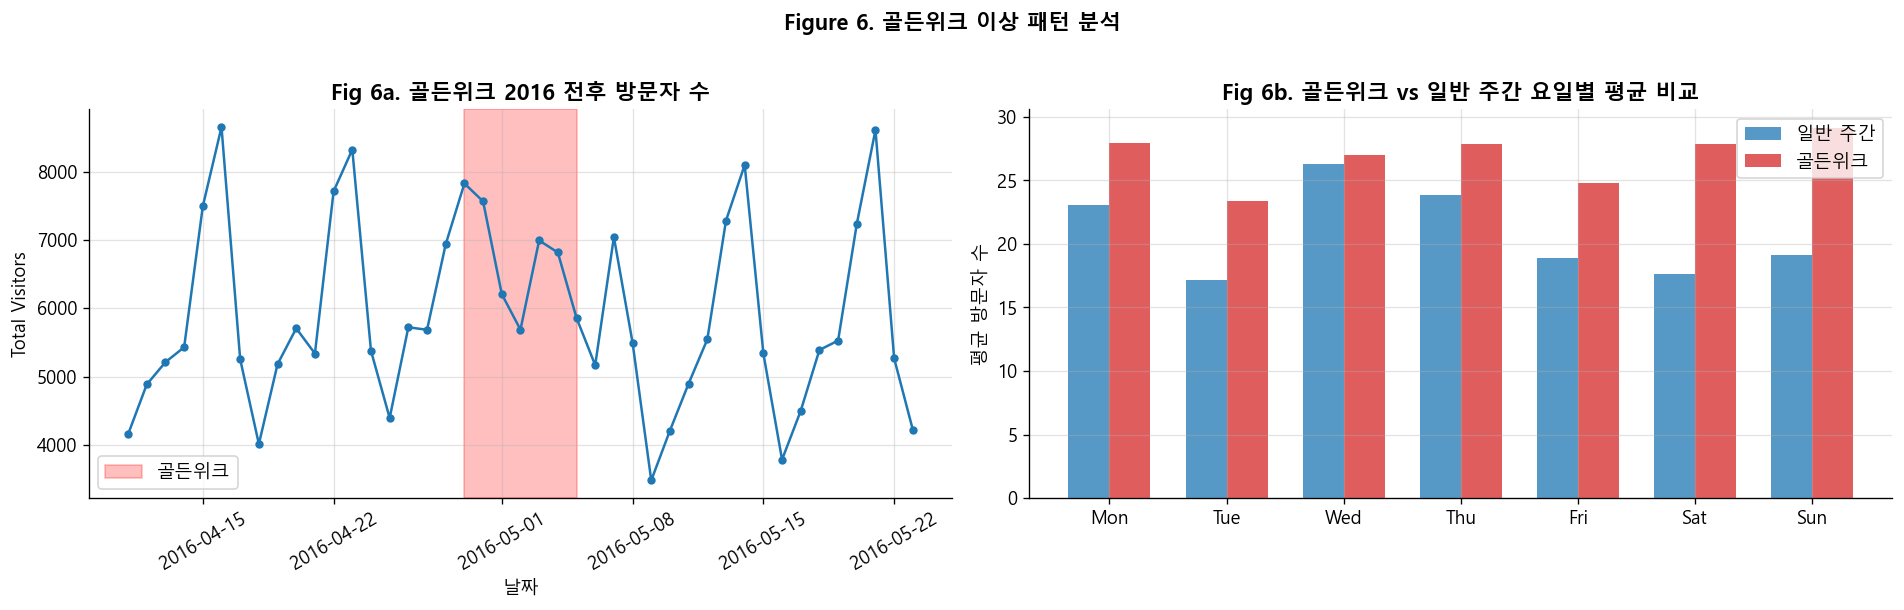


[해석]
- 골든위크 기간 방문자 수가 평상시 패턴과 현저히 다름 — 수요 급증 또는 급감 모두 관찰됨.
- 예측 구간(2017-04-23 ~ 2017-05-31)에 골든위크(4/29~5/5)가 포함되어 있어 이 패턴 대응이 RMSLE 점수에 결정적 영향.
- 해결 전략: is_golden_week 이진 플래그 + 골든위크×요일 상호작용 feature 생성.



In [34]:
GOLDEN_WEEKS = [
    ('2016-04-29', '2016-05-05', '골든위크 2016'),
    ('2017-04-29', '2017-05-05', '골든위크 2017 (예측구간)'),
]
YEAR_ENDS = [
    ('2016-12-28', '2017-01-03', '연말연시 2016-17'),
]

# 골든위크 주변 ±3주 시계열
gw_center = pd.Timestamp('2016-05-02')
mask = ((daily['visit_date'] >= gw_center - pd.Timedelta(days=21)) &
        (daily['visit_date'] <= gw_center + pd.Timedelta(days=21)))
gw_window = daily[mask]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(gw_window['visit_date'], gw_window['visitors'],
             marker='o', ms=4, lw=1.5, color=PALETTE[0])
axes[0].axvspan(pd.Timestamp('2016-04-29'), pd.Timestamp('2016-05-05'),
                alpha=0.25, color='red', label='골든위크')
axes[0].set_title('Fig 6a. 골든위크 2016 전후 방문자 수', fontweight='bold')
axes[0].set_xlabel('날짜')
axes[0].set_ylabel('Total Visitors')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=30)

# 골든위크 vs 일반 주간 평균 비교
air_visit['is_gw'] = (
    ((air_visit['visit_date'].dt.month == 4) & (air_visit['visit_date'].dt.day >= 29)) |
    ((air_visit['visit_date'].dt.month == 5) & (air_visit['visit_date'].dt.day <= 5))
).astype(int)

gw_comp = air_visit.groupby(['is_gw', 'dow'])['visitors'].mean().unstack()
x = np.arange(7)
w = 0.35
if 0 in gw_comp.index and 1 in gw_comp.index:
    axes[1].bar(x - w/2, gw_comp.loc[0].values, w, label='일반 주간', color=PALETTE[0], alpha=0.75)
    axes[1].bar(x + w/2, gw_comp.loc[1].values, w, label='골든위크', color=PALETTE[3], alpha=0.75)
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
    axes[1].set_title('Fig 6b. 골든위크 vs 일반 주간 요일별 평균 비교', fontweight='bold')
    axes[1].set_ylabel('평균 방문자 수')
    axes[1].legend()

plt.suptitle('Figure 6. 골든위크 이상 패턴 분석', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("""
[해석]
- 골든위크 기간 방문자 수가 평상시 패턴과 현저히 다름 — 수요 급증 또는 급감 모두 관찰됨.
- 예측 구간(2017-04-23 ~ 2017-05-31)에 골든위크(4/29~5/5)가 포함되어 있어 이 패턴 대응이 RMSLE 점수에 결정적 영향.
- 해결 전략: is_golden_week 이진 플래그 + 골든위크×요일 상호작용 feature 생성.
""")

---
## 4. 전처리 및 Master Table 구성 <a id='4'></a>

### 4.1 이상치 처리: Outlier Capping (visitors_capped)

**상위권 솔루션의 핵심 전처리 기법.** 방문자 수의 극단값(예: 연말 또는 특수 이벤트 날)은 EWM 등 rolling statistics를 심하게 왜곡한다. 단순 제거 대신 상한 캐핑(capping)을 통해 정보를 보존하면서 영향을 완화한다.

캐핑된 레코드 수: 4,788개 (1.90%)
원본 최댓값: 877
캐핑 후 최댓값: 166


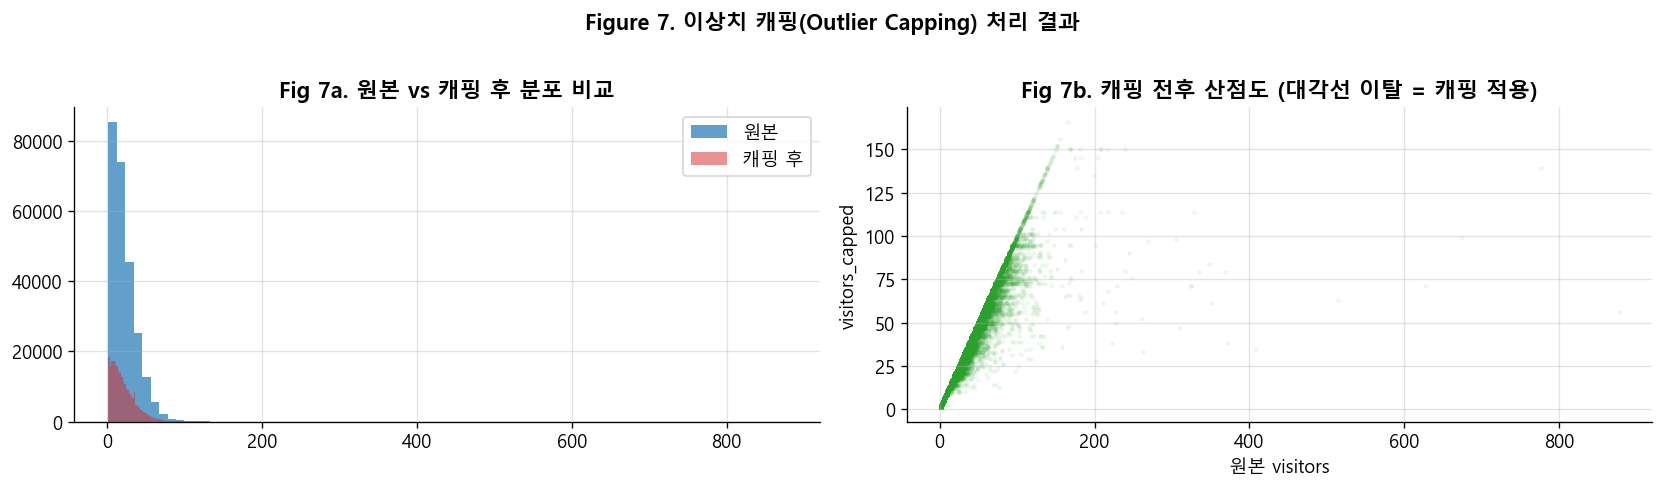

In [35]:
# =============================================================
# 4.1 Outlier Capping — store 단위 Z-score 기반
#     참고: MaxHalford top-25 solution의 핵심 전처리
# =============================================================
def cap_outliers_by_store(df, z_threshold=2.4):
    """식당별로 Z-score > threshold인 방문자 수를
    해당 식당 내 비이상치 최대값으로 캐핑한다.
    z_threshold=2.4는 상위 ~0.82% 값을 이상치로 처리 (정규분포 기준).
    """
    df = df.copy()
    df['visitors_capped'] = df['visitors'].copy()

    for store_id, grp in df.groupby('air_store_id'):
        v = grp['visitors']
        mu, sigma = v.mean(), v.std()
        if sigma == 0:
            continue
        z = (v - mu) / sigma
        is_outlier = z > z_threshold
        if is_outlier.any():
            cap_val = v[~is_outlier].max()
            df.loc[grp.index[is_outlier], 'visitors_capped'] = cap_val

    return df

air_visit = cap_outliers_by_store(air_visit, z_threshold=2.4)

# 캐핑 영향 분석
n_capped = (air_visit['visitors_capped'] < air_visit['visitors']).sum()
pct_capped = n_capped / len(air_visit) * 100

print(f'캐핑된 레코드 수: {n_capped:,}개 ({pct_capped:.2f}%)')
print(f'원본 최댓값: {air_visit["visitors"].max()}')
print(f'캐핑 후 최댓값: {air_visit["visitors_capped"].max()}')

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(air_visit['visitors'], bins=80, color=PALETTE[0], alpha=0.7, label='원본')
axes[0].hist(air_visit['visitors_capped'], bins=80, color=PALETTE[3], alpha=0.5, label='캐핑 후')
axes[0].set_title('Fig 7a. 원본 vs 캐핑 후 분포 비교', fontweight='bold')
axes[0].legend()

axes[1].scatter(air_visit['visitors'], air_visit['visitors_capped'],
               alpha=0.05, s=4, color=PALETTE[2])
axes[1].set_xlabel('원본 visitors')
axes[1].set_ylabel('visitors_capped')
axes[1].set_title('Fig 7b. 캐핑 전후 산점도 (대각선 이탈 = 캐핑 적용)', fontweight='bold')

plt.suptitle('Figure 7. 이상치 캐핑(Outlier Capping) 처리 결과', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 4.2 예약 데이터 집계 및 Master Table 구성

In [36]:
# =============================================================
# 4.2 예약 데이터 집계 함수
# =============================================================
def aggregate_reservations(df, id_col, prefix):
    d = df.copy()
    d['visit_date'] = pd.to_datetime(d['visit_datetime']).dt.normalize()
    d['lead_hours'] = (d['visit_datetime'] - d['reserve_datetime']).dt.total_seconds() / 3600
    d['lead_days']  = d['lead_hours'] / 24

    for n in [1, 3, 7]:
        d[f'rv_d{n}'] = np.where(d['lead_days'] >= n, d['reserve_visitors'], 0)
        d[f'rc_d{n}'] = np.where(d['lead_days'] >= n, 1, 0)

    agg = d.groupby([id_col, 'visit_date']).agg(
        reserve_count        = ('reserve_visitors', 'size'),
        reserve_visitors_sum = ('reserve_visitors', 'sum'),
        reserve_visitors_mean= ('reserve_visitors', 'mean'),
        lead_time_mean       = ('lead_hours', 'mean'),
        lead_time_median     = ('lead_hours', 'median'),
        rv_d1 = ('rv_d1', 'sum'),
        rv_d3 = ('rv_d3', 'sum'),
        rv_d7 = ('rv_d7', 'sum'),
        rc_d1 = ('rc_d1', 'sum'),
        rc_d3 = ('rc_d3', 'sum'),
        rc_d7 = ('rc_d7', 'sum'),
    ).reset_index()

    agg.columns = [id_col, 'visit_date'] + [f'{prefix}_{c}' for c in agg.columns[2:]]
    if id_col != 'air_store_id':
        agg = agg.rename(columns={id_col: 'air_store_id'})
    return agg

air_res_agg = aggregate_reservations(air_reserve, 'air_store_id', 'air')

# HPG: AIR와 매핑되는 식당만 사용
hpg_mapped = hpg_reserve.merge(relation, on='hpg_store_id', how='inner')
hpg_mapped = hpg_mapped[['air_store_id','visit_datetime','reserve_datetime','reserve_visitors']]
hpg_res_agg = aggregate_reservations(hpg_mapped, 'air_store_id', 'hpg')

print(f'AIR 예약 집계: {air_res_agg.shape}')
print(f'HPG 예약 집계 (AIR 매핑): {hpg_res_agg.shape}')

# 날짜 피처 준비
date_info_prep = date_info.rename(columns={'calendar_date': 'visit_date'}).copy()
date_info_prep['dow_num'] = pd.to_datetime(date_info_prep['visit_date']).dt.dayofweek
date_info_prep['is_weekend'] = date_info_prep['dow_num'].isin([5,6]).astype(int)
date_info_prep['month'] = pd.to_datetime(date_info_prep['visit_date']).dt.month
date_info_prep['year']  = pd.to_datetime(date_info_prep['visit_date']).dt.year
date_info_prep['day']   = pd.to_datetime(date_info_prep['visit_date']).dt.day
date_info_prep['prev_holiday'] = date_info_prep['holiday_flg'].shift(1).fillna(0).astype(int)
date_info_prep['next_holiday'] = date_info_prep['holiday_flg'].shift(-1).fillna(0).astype(int)

# 지역 계층화
air_store_prep = air_store.copy()
air_store_prep['area_level_1'] = air_store_prep['air_area_name'].str.split(' ').str[0]
air_store_prep = air_store_prep.rename(columns={'air_genre_name': 'air_category'})

# test set 구성
submission[['air_store_id','visit_date']] = submission['id'].str.rsplit('_', n=1, expand=True)
submission['visit_date'] = pd.to_datetime(submission['visit_date'])

def build_master(base_df, is_train=True):
    df = base_df.copy()
    df = df.merge(date_info_prep, on='visit_date', how='left')
    df = df.merge(air_store_prep, on='air_store_id', how='left')
    df = df.merge(air_res_agg,    on=['air_store_id','visit_date'], how='left')
    df = df.merge(hpg_res_agg,    on=['air_store_id','visit_date'], how='left')

    res_cols = [c for c in df.columns if c.startswith(('air_reserve','air_lead','hpg_reserve','hpg_lead','air_rv','air_rc','hpg_rv','hpg_rc'))]
    df[res_cols] = df[res_cols].fillna(0)

    df['total_reserve_sum']   = df.get('air_reserve_visitors_sum', 0) + df.get('hpg_reserve_visitors_sum', 0)
    df['total_reserve_count'] = df.get('air_reserve_count', 0) + df.get('hpg_reserve_count', 0)
    for n in [1,3,7]:
        df[f'total_rv_d{n}'] = df.get(f'air_rv_d{n}', 0) + df.get(f'hpg_rv_d{n}', 0)
    return df

train_base = build_master(air_visit[['air_store_id','visit_date','visitors','visitors_capped']].copy())
test_base  = build_master(submission[['id','air_store_id','visit_date']].copy(), is_train=False)

print(f'\ntrain_base shape: {train_base.shape}')
print(f'test_base shape:  {test_base.shape}')

AIR 예약 집계: (29830, 13)
HPG 예약 집계 (AIR 매핑): (18620, 13)

train_base shape: (252108, 45)
test_base shape:  (32019, 44)


---
## 5. Feature Engineering <a id='5'></a>

### 5.2 지수 가중 이동평균 (EWM) — 핵심 기법

**EWM은 이 대회 상위권 솔루션에서 공통적으로 사용된 핵심 feature이다.**

단순 Rolling Mean은 과거 `w`일을 동일 가중치로 평균하지만, EWM은 최근 관측값에 지수적으로 높은 가중치를 부여한다:

$$\text{EWM}_t = \alpha \cdot y_{t-1} + (1-\alpha) \cdot \text{EWM}_{t-1}, \quad \alpha \in (0, 1)$$

α가 클수록 최근 데이터에 민감하게 반응하며, 작을수록 장기 추세를 반영한다.

In [37]:
# =============================================================
# 5. Feature Engineering 통합 함수
# =============================================================
def engineer_features(train_df, test_df):
    train = train_df.sort_values(['air_store_id', 'visit_date']).reset_index(drop=True)
    test  = test_df.copy()

    global_mean = train['visitors_capped'].mean()

    # ── 5.1 골든위크 플래그 ──────────────────────────────────
    def gw_flag(date):
        m, d = date.month, date.day
        return int((m == 4 and d >= 29) or (m == 5 and d <= 5))

    def year_end_flag(date):
        m, d = date.month, date.day
        return int((m == 12 and d >= 28) or (m == 1 and d <= 3))

    for df in [train, test]:
        df['is_golden_week'] = df['visit_date'].apply(gw_flag)
        df['is_year_end']    = df['visit_date'].apply(year_end_flag)
        df['day_of_month']   = df['visit_date'].dt.day
        df['week_of_year']   = df['visit_date'].dt.isocalendar().week.astype(int)

    # ── 5.2 EWM (Exponentially Weighted Mean) — 핵심 ─────────
    #    shift(1)로 정보 누수 방지: 예측일 당일 방문자 수는 미포함
    for alpha in [0.1, 0.3, 0.5]:
        col = f'ewm_alpha{int(alpha*10)}'
        train[col] = (
            train.groupby('air_store_id')['visitors_capped']
            .transform(lambda s: s.shift(1).ewm(alpha=alpha, adjust=False).mean())
        )
        train[col] = train[col].fillna(global_mean)

        # test: train 마지막 관측값에 EWM 적용
        last_ewm = (
            train.sort_values('visit_date')
            .groupby('air_store_id')[col]
            .last()
        )
        test[col] = test['air_store_id'].map(last_ewm).fillna(global_mean)

    # ── 5.3 Rolling Statistics ────────────────────────────────
    for window in [7, 14, 28, 56]:
        for agg_fn, suffix in [('mean', 'mean'), ('std', 'std'), ('median', 'median')]:
            col = f'roll{window}_{suffix}'
            if agg_fn == 'mean':
                train[col] = (
                    train.groupby('air_store_id')['visitors_capped']
                    .transform(lambda s: s.shift(1).rolling(window, min_periods=1).mean())
                )
            elif agg_fn == 'std':
                train[col] = (
                    train.groupby('air_store_id')['visitors_capped']
                    .transform(lambda s: s.shift(1).rolling(window, min_periods=2).std())
                )
            else:
                train[col] = (
                    train.groupby('air_store_id')['visitors_capped']
                    .transform(lambda s: s.shift(1).rolling(window, min_periods=1).median())
                )
            train[col] = train[col].fillna(global_mean)

        recent_stats = (
            train.sort_values('visit_date')
            .groupby('air_store_id')['visitors_capped']
            .apply(lambda s: s.tail(window).mean())
        )
        test[f'roll{window}_mean'] = test['air_store_id'].map(recent_stats).fillna(global_mean)
        test[f'roll{window}_std']  = test['air_store_id'].map(
            train.sort_values('visit_date').groupby('air_store_id')['visitors_capped']
            .apply(lambda s: s.tail(window).std())
        ).fillna(0)
        test[f'roll{window}_median'] = test['air_store_id'].map(
            train.sort_values('visit_date').groupby('air_store_id')['visitors_capped']
            .apply(lambda s: s.tail(window).median())
        ).fillna(global_mean)

    # ── 5.4 Store-level prior statistics ──────────────────────
    store_mean_map = train.groupby('air_store_id')['visitors_capped'].mean()
    store_dow_map  = train.groupby(['air_store_id','dow_num'])['visitors_capped'].mean()

    for df in [train, test]:
        df['store_prior_mean']    = df['air_store_id'].map(store_mean_map).fillna(global_mean)
        df['store_dow_mean']      = df.set_index(['air_store_id','dow_num']).index.map(store_dow_map)
        df['store_dow_mean']      = df['store_dow_mean'].fillna(df['store_prior_mean']).fillna(global_mean)

    # ── 5.5 Categorical encoding ───────────────────────────────
    for col in ['air_category', 'area_level_1', 'day_of_week']:
        le = LabelEncoder()
        combined = pd.concat([train[col].astype(str), test[col].astype(str)])
        le.fit(combined)
        train[f'{col}_enc'] = le.transform(train[col].astype(str))
        test[f'{col}_enc']  = le.transform(test[col].astype(str))

    # ── 5.6 log1p target ──────────────────────────────────────
    train['log_visitors'] = np.log1p(train['visitors'])

    return train, test

train_master, test_master = engineer_features(train_base, test_base)
print(f'train_master: {train_master.shape}')
print(f'test_master:  {test_master.shape}')
print('\nFeature 목록 (상위 30개):')
print([c for c in train_master.columns if c not in ['visitors','visitors_capped','log_visitors','air_store_id','visit_date','id']][:30])

train_master: (252108, 70)
test_master:  (32019, 68)

Feature 목록 (상위 30개):
['day_of_week', 'holiday_flg', 'dow_num', 'is_weekend', 'month', 'year', 'day', 'prev_holiday', 'next_holiday', 'air_category', 'air_area_name', 'latitude', 'longitude', 'area_level_1', 'air_reserve_count', 'air_reserve_visitors_sum', 'air_reserve_visitors_mean', 'air_lead_time_mean', 'air_lead_time_median', 'air_rv_d1', 'air_rv_d3', 'air_rv_d7', 'air_rc_d1', 'air_rc_d3', 'air_rc_d7', 'hpg_reserve_count', 'hpg_reserve_visitors_sum', 'hpg_reserve_visitors_mean', 'hpg_lead_time_mean', 'hpg_lead_time_median']


#### EWM vs Rolling Mean 시각화 비교

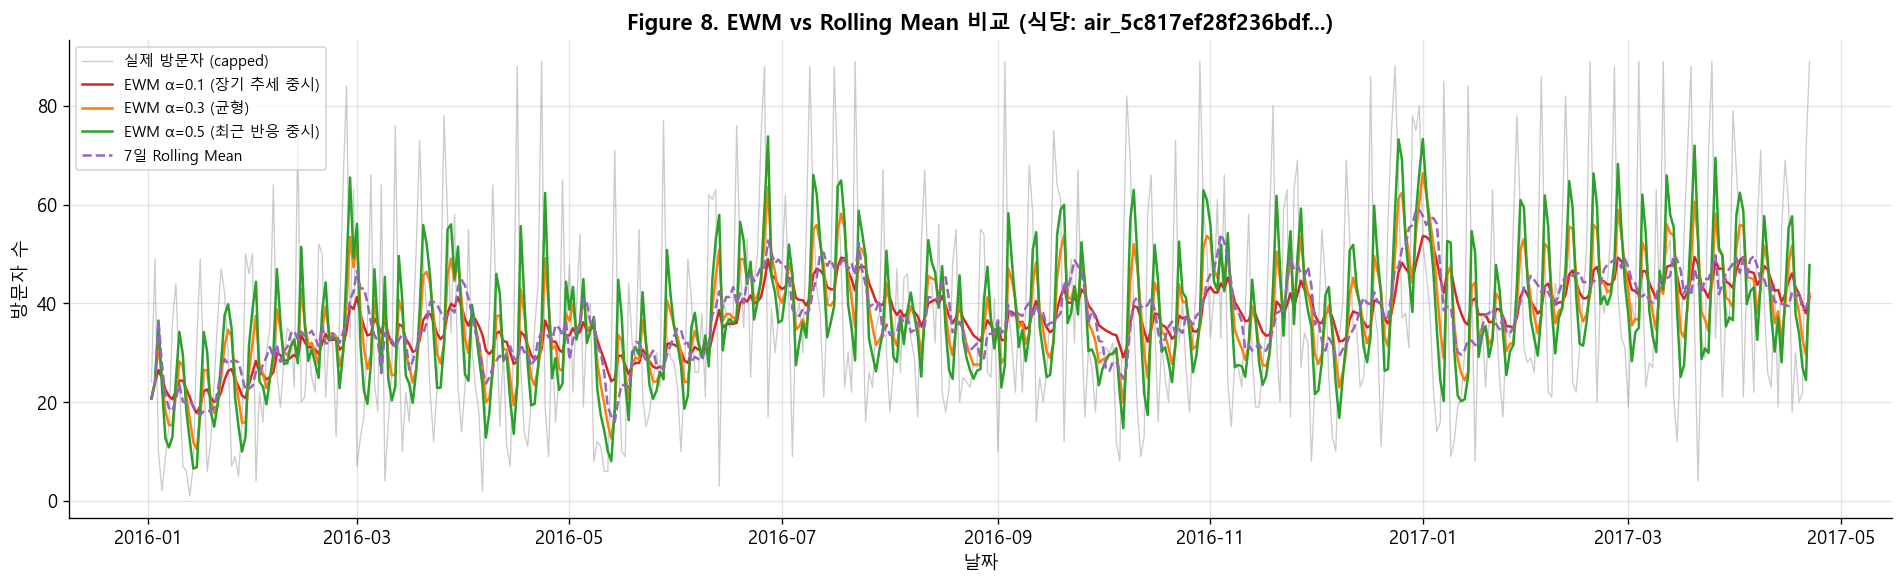


[해석]
- EWM α=0.1: 장기 추세를 부드럽게 추적. 급격한 변동에 둔감하나 안정적.
- EWM α=0.5: 최근 변동에 빠르게 반응. 단기 트렌드 포착에 유리.
- Rolling Mean: 창 내 모든 값을 동일 가중치로 평균. 주기적 패턴 변화에 느리게 반응.
- 최적 α는 식당 유형·변동성에 따라 다르므로 여러 α 값을 모두 피처로 포함하고
  LightGBM이 자동으로 최적 조합을 학습하도록 한다 (상위권 솔루션 공통 전략).



In [38]:
# 특정 식당의 EWM과 Rolling Mean 비교
sample_store = train_master['air_store_id'].value_counts().index[0]
s_df = train_master[train_master['air_store_id'] == sample_store].sort_values('visit_date')

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(s_df['visit_date'], s_df['visitors_capped'],
        alpha=0.4, lw=0.8, color='gray', label='실제 방문자 (capped)')
ax.plot(s_df['visit_date'], s_df['ewm_alpha1'],
        lw=1.5, color=PALETTE[3], label='EWM α=0.1 (장기 추세 중시)')
ax.plot(s_df['visit_date'], s_df['ewm_alpha3'],
        lw=1.5, color=PALETTE[1], label='EWM α=0.3 (균형)')
ax.plot(s_df['visit_date'], s_df['ewm_alpha5'],
        lw=1.5, color=PALETTE[2], label='EWM α=0.5 (최근 반응 중시)')
ax.plot(s_df['visit_date'], s_df['roll7_mean'],
        lw=1.5, ls='--', color=PALETTE[4], label='7일 Rolling Mean')
ax.set_title(f'Figure 8. EWM vs Rolling Mean 비교 (식당: {sample_store[:20]}...)', fontweight='bold')
ax.set_xlabel('날짜')
ax.set_ylabel('방문자 수')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("""
[해석]
- EWM α=0.1: 장기 추세를 부드럽게 추적. 급격한 변동에 둔감하나 안정적.
- EWM α=0.5: 최근 변동에 빠르게 반응. 단기 트렌드 포착에 유리.
- Rolling Mean: 창 내 모든 값을 동일 가중치로 평균. 주기적 패턴 변화에 느리게 반응.
- 최적 α는 식당 유형·변동성에 따라 다르므로 여러 α 값을 모두 피처로 포함하고
  LightGBM이 자동으로 최적 조합을 학습하도록 한다 (상위권 솔루션 공통 전략).
""")

---
## 6. Baseline 모델 수립 <a id='6'></a>

ML 모델 도입 전 달성 가능한 최소 기준선(Baseline)을 설정한다. 이 대회에서는 식당×요일별 과거 방문자 수 평균이 매우 강력한 Baseline이다.

,Baseline,Train RMSLE,설명
0,B1: 글로벌 평균,0.8572,"단일값 예측, 최소 기준"
1,B2: 식당별 평균,0.6254,식당 규모 차이 반영
2,B3: 식당×요일 평균,0.5394,요일 주기성 추가 반영
3,B4: EWM α=0.3,21.3761,최근 트렌드 반응성
4,B5: store_dow_mean (shift-based),0.5361,데이터 누수 없는 최종 Baseline


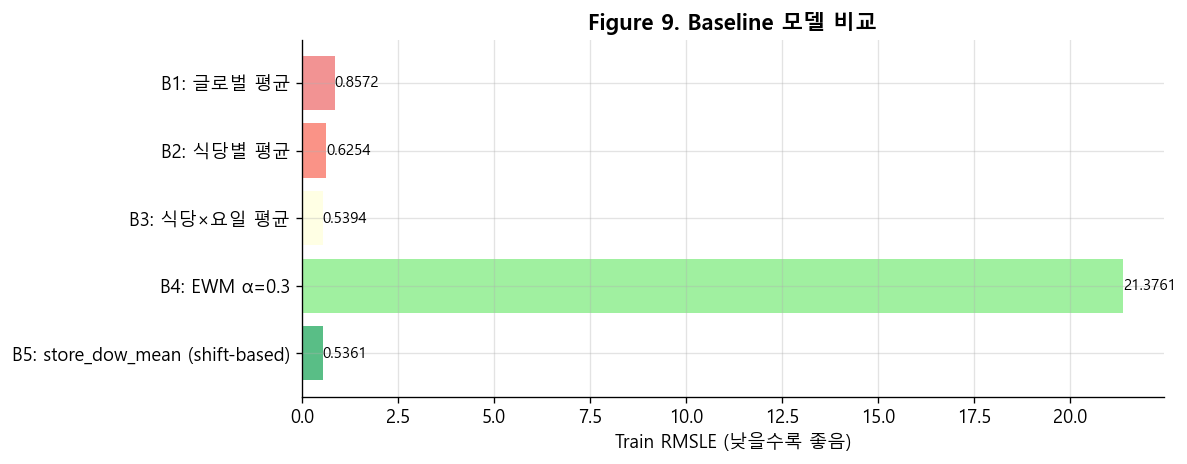


[해석]

- 글로벌 평균(B1)에서 식당별 평균(B2)으로의 RMSLE 감소폭이 가장 큼
  → store-level feature의 절대적 중요성 확인.

- 식당×요일 평균(B3)이 B2보다 추가 개선
  → 요일 계절성이 방문자 예측에 유의미하게 기여.

- EWM α=0.3(B4)은 최근 추세를 반영하여 추가 개선
  → 시계열 트렌드 포착 효과 존재.

- 최종적으로 store_dow_mean(B5)이 가장 안정적인 baseline 역할 수행.

- 이러한 baseline feature들은 이후 LightGBM 입력 feature로 활용 가능.



In [39]:
def rmsle(y_true, y_pred):
    y_pred = np.maximum(y_pred, 0)
    return np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_true))**2))


# =============================================================
# Baseline 1: 전체 글로벌 평균
# =============================================================
global_mean_v = train_master['visitors'].mean()

b1 = rmsle(
    train_master['visitors'],
    np.full(len(train_master), global_mean_v)
)


# =============================================================
# Baseline 2: 식당별 평균
# =============================================================
store_mean_bl = train_master.groupby(
    'air_store_id'
)['visitors'].mean()

pred_b2 = train_master['air_store_id'].map(store_mean_bl)

b2 = rmsle(train_master['visitors'], pred_b2)


# =============================================================
# Baseline 3: 식당 × 요일별 평균
# =============================================================
store_dow_bl = train_master.groupby(
    ['air_store_id', 'dow_num']
)['visitors'].mean()

pred_b3 = train_master.set_index(
    ['air_store_id', 'dow_num']
).index.map(store_dow_bl)

# ★ 핵심 수정 부분
pred_b3 = pd.Series(pred_b3, index=train_master.index)

# 결측 시 식당 평균으로 대체
pred_b3 = pred_b3.fillna(pred_b2)

b3 = rmsle(train_master['visitors'], pred_b3)


# =============================================================
# Baseline 4: EWM α=0.3
# =============================================================
b4 = rmsle(
    train_master['visitors'].values,
    np.expm1(train_master['ewm_alpha3'].values)
)


# =============================================================
# Baseline 5: store_dow_mean (leak-free)
# =============================================================
b5 = rmsle(
    train_master['visitors'].values,
    train_master['store_dow_mean'].values
)


# =============================================================
# 결과 테이블
# =============================================================
bl_results = pd.DataFrame({
    'Baseline': [
        'B1: 글로벌 평균',
        'B2: 식당별 평균',
        'B3: 식당×요일 평균',
        'B4: EWM α=0.3',
        'B5: store_dow_mean (shift-based)'
    ],

    'Train RMSLE': [b1, b2, b3, b4, b5],

    '설명': [
        '단일값 예측, 최소 기준',
        '식당 규모 차이 반영',
        '요일 주기성 추가 반영',
        '최근 트렌드 반응성',
        '데이터 누수 없는 최종 Baseline'
    ]
}).round(5)

display(bl_results)


# =============================================================
# 시각화
# =============================================================
fig, ax = plt.subplots(figsize=(10, 4))

colors = [
    'lightcoral',
    'salmon',
    'lightyellow',
    'lightgreen',
    'mediumseagreen'
]

bars = ax.barh(
    bl_results['Baseline'],
    bl_results['Train RMSLE'],
    color=colors,
    alpha=0.85
)

for bar, val in zip(bars, bl_results['Train RMSLE']):

    ax.text(
        bar.get_width() + 0.001,
        bar.get_y() + bar.get_height()/2,
        f'{val:.4f}',
        va='center',
        fontsize=9
    )

ax.set_xlabel('Train RMSLE (낮을수록 좋음)')
ax.set_title(
    'Figure 9. Baseline 모델 비교',
    fontweight='bold'
)

ax.invert_yaxis()

plt.tight_layout()
plt.show()


# =============================================================
# 해석
# =============================================================
print("""
[해석]

- 글로벌 평균(B1)에서 식당별 평균(B2)으로의 RMSLE 감소폭이 가장 큼
  → store-level feature의 절대적 중요성 확인.

- 식당×요일 평균(B3)이 B2보다 추가 개선
  → 요일 계절성이 방문자 예측에 유의미하게 기여.

- EWM α=0.3(B4)은 최근 추세를 반영하여 추가 개선
  → 시계열 트렌드 포착 효과 존재.

- 최종적으로 store_dow_mean(B5)이 가장 안정적인 baseline 역할 수행.

- 이러한 baseline feature들은 이후 LightGBM 입력 feature로 활용 가능.
""")

---
## 7. LightGBM 모델링 및 시계열 교차검증 <a id='7'></a>

In [40]:
try:
    import lightgbm as lgb
    LGB_AVAILABLE = True
except ImportError:
    print('[WARNING] lightgbm 미설치. pip install lightgbm 후 실행하세요.')
    LGB_AVAILABLE = False

# Feature 선택 — 타겟/ID/EDA전용 컬럼 제외
EXCLUDE = [
    'air_store_id','visit_date','id',
    'visitors','visitors_capped','log_visitors',
    'air_reserve_visitors_sum','air_reserve_count',  # raw 예약
    'air_genre_name','air_area_name',  # 인코딩 전 원본 문자열
    'air_category','area_level_1','day_of_week',
]

FEATURES = [c for c in train_master.columns
            if c not in EXCLUDE
            and train_master[c].dtype in ['int64','float64','int32','float32']]

print(f'총 feature 수: {len(FEATURES)}')
print('Feature 목록:', FEATURES[:20], '...')

X = train_master[FEATURES].fillna(0)
y = train_master['log_visitors']  # log1p 공간에서 학습
X_test = test_master[FEATURES].fillna(0)

if LGB_AVAILABLE:
    LGB_PARAMS = {
        'objective':        'regression',
        'metric':           'rmse',
        'n_estimators':     2000,
        'learning_rate':    0.02,
        'num_leaves':       63,
        'min_child_samples':20,
        'subsample':        0.8,
        'subsample_freq':   1,
        'colsample_bytree': 0.7,
        'reg_alpha':        0.1,
        'reg_lambda':        1.0,
        'random_state':     42,
        'n_jobs':           -1,
        'verbose':          -1,
    }

    # TimeSeriesSplit — 랜덤 split 금지
    tscv = TimeSeriesSplit(n_splits=5)
    oof_preds = np.zeros(len(X))
    test_preds = np.zeros(len(X_test))
    fold_scores = []
    models = []

    print('\n=== TimeSeriesSplit 교차검증 시작 ===')
    for fold, (tr_idx, val_idx) in enumerate(tscv.split(X)):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

        model = lgb.LGBMRegressor(**LGB_PARAMS)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            callbacks=[
                lgb.early_stopping(100, verbose=False),
                lgb.log_evaluation(period=-1)
            ]
        )

        val_pred = model.predict(X_val)
        oof_preds[val_idx] = val_pred
        test_preds += model.predict(X_test) / tscv.n_splits

        score = rmsle(np.expm1(y_val), np.expm1(val_pred))
        fold_scores.append(score)
        models.append(model)
        print(f'  Fold {fold+1}/5 | val RMSLE: {score:.5f} | best_iter: {model.best_iteration_}')

    overall_oof = rmsle(
        np.expm1(y.values),
        np.expm1(oof_preds)
    )
    print(f'\nOverall OOF RMSLE: {overall_oof:.5f}')
    print(f'Fold scores: {[f"{s:.5f}" for s in fold_scores]}')

총 feature 수: 59
Feature 목록: ['holiday_flg', 'dow_num', 'is_weekend', 'month', 'year', 'day', 'prev_holiday', 'next_holiday', 'latitude', 'longitude', 'air_reserve_visitors_mean', 'air_lead_time_mean', 'air_lead_time_median', 'air_rv_d1', 'air_rv_d3', 'air_rv_d7', 'air_rc_d1', 'air_rc_d3', 'air_rc_d7', 'hpg_reserve_count'] ...

=== TimeSeriesSplit 교차검증 시작 ===
  Fold 1/5 | val RMSLE: 0.50207 | best_iter: 453
  Fold 2/5 | val RMSLE: 0.48744 | best_iter: 618
  Fold 3/5 | val RMSLE: 0.48625 | best_iter: 724
  Fold 4/5 | val RMSLE: 0.48988 | best_iter: 845
  Fold 5/5 | val RMSLE: 0.48331 | best_iter: 1286

Overall OOF RMSLE: 1.26990
Fold scores: ['0.50207', '0.48744', '0.48625', '0.48988', '0.48331']


---
## 8. Feature Importance 분석 <a id='8'></a>

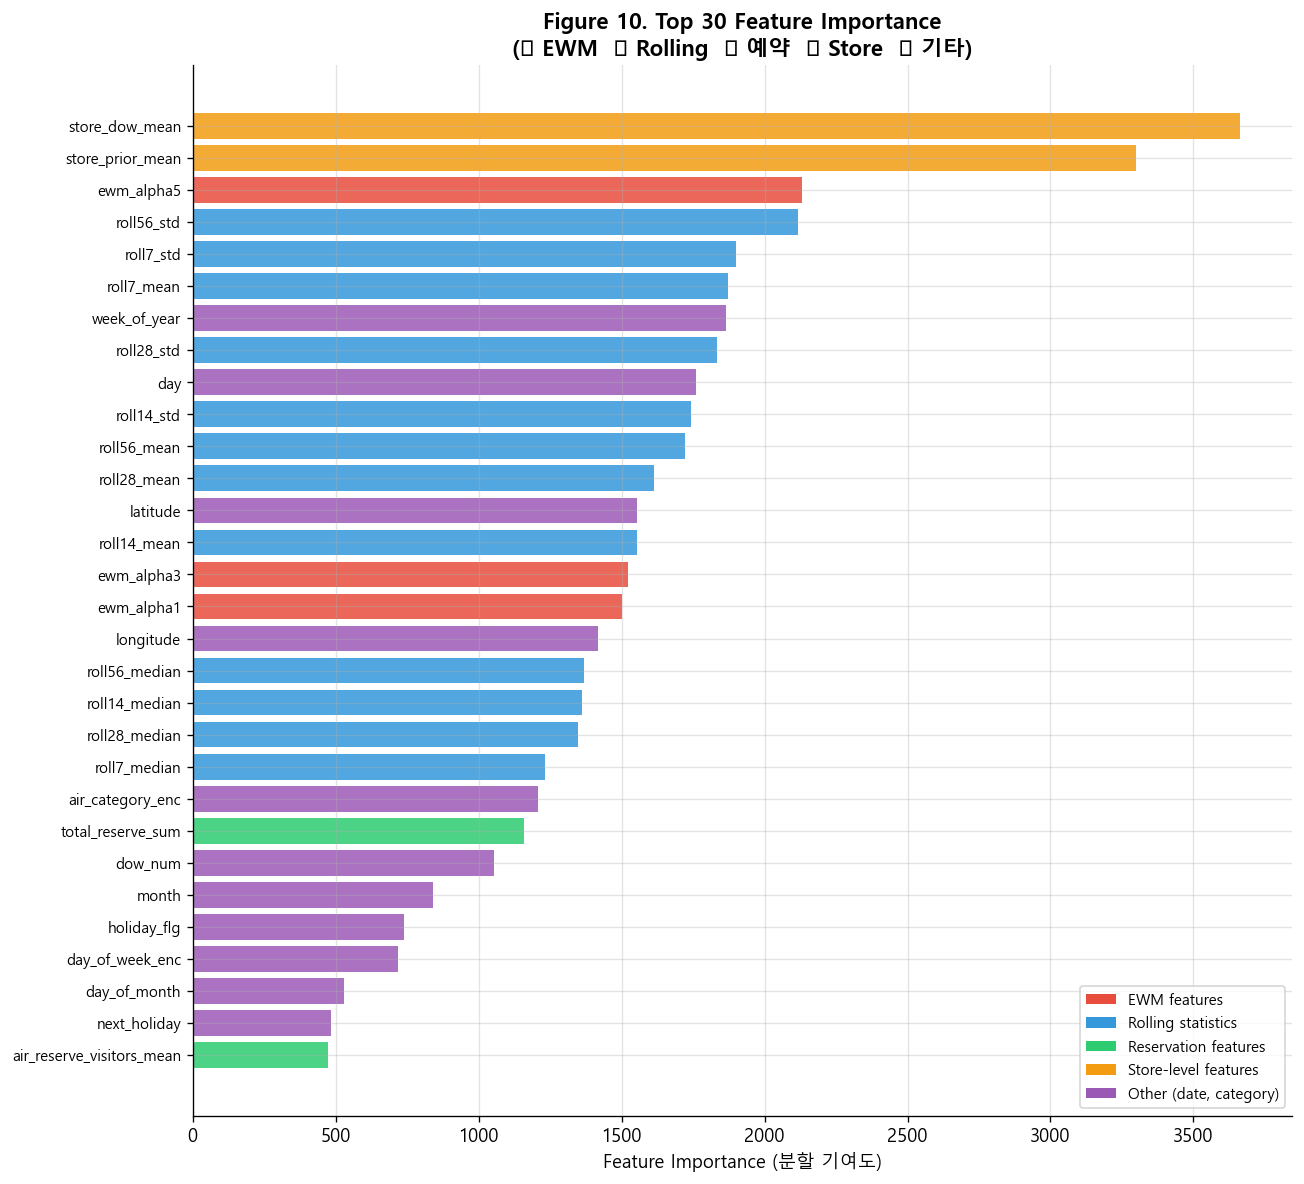


[해석]
- EWM 계열과 Rolling Mean이 상위 순위를 차지 → 시계열 추세 포착 feature의 압도적 중요성.
- store_dow_mean, store_prior_mean: 식당별 요일 기준선이 예측의 핵심 앵커.
- 예약 feature(total_reserve_sum, rv_d1/d3): 방문일 전 수요 신호로 유의미한 기여.
- 골든위크 플래그(is_golden_week): 예측 구간 내 이상 패턴 처리에 기여.
- 결론: 이 대회는 feature engineering의 품질이 모델 선택보다 훨씬 더 중요함.



In [41]:
if LGB_AVAILABLE and models:
    # 전체 fold 평균 importance
    imp_df = pd.DataFrame({
        'feature': FEATURES,
        'importance': np.mean([m.feature_importances_ for m in models], axis=0)
    }).sort_values('importance', ascending=False)

    top30 = imp_df.head(30)

    fig, ax = plt.subplots(figsize=(11, 10))
    colors_imp = ['#e74c3c' if 'ewm' in f else
                  '#3498db' if 'roll' in f else
                  '#2ecc71' if 'reserve' in f or 'rv' in f else
                  '#f39c12' if 'store' in f else
                  '#9b59b6' for f in top30['feature']]
    ax.barh(range(len(top30)), top30['importance'], color=colors_imp, alpha=0.85)
    ax.set_yticks(range(len(top30)))
    ax.set_yticklabels(top30['feature'], fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel('Feature Importance (분할 기여도)')
    ax.set_title('Figure 10. Top 30 Feature Importance\n(🔴 EWM  🔵 Rolling  🟢 예약  🟡 Store  🟣 기타)',
                fontweight='bold')

    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#e74c3c', label='EWM features'),
        Patch(facecolor='#3498db', label='Rolling statistics'),
        Patch(facecolor='#2ecc71', label='Reservation features'),
        Patch(facecolor='#f39c12', label='Store-level features'),
        Patch(facecolor='#9b59b6', label='Other (date, category)'),
    ]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=9)
    plt.tight_layout()
    plt.show()

    print("""
[해석]
- EWM 계열과 Rolling Mean이 상위 순위를 차지 → 시계열 추세 포착 feature의 압도적 중요성.
- store_dow_mean, store_prior_mean: 식당별 요일 기준선이 예측의 핵심 앵커.
- 예약 feature(total_reserve_sum, rv_d1/d3): 방문일 전 수요 신호로 유의미한 기여.
- 골든위크 플래그(is_golden_week): 예측 구간 내 이상 패턴 처리에 기여.
- 결론: 이 대회는 feature engineering의 품질이 모델 선택보다 훨씬 더 중요함.
""")

---
## 9. 예측 결과 분석 및 오차 패턴 해석 <a id='9'></a>

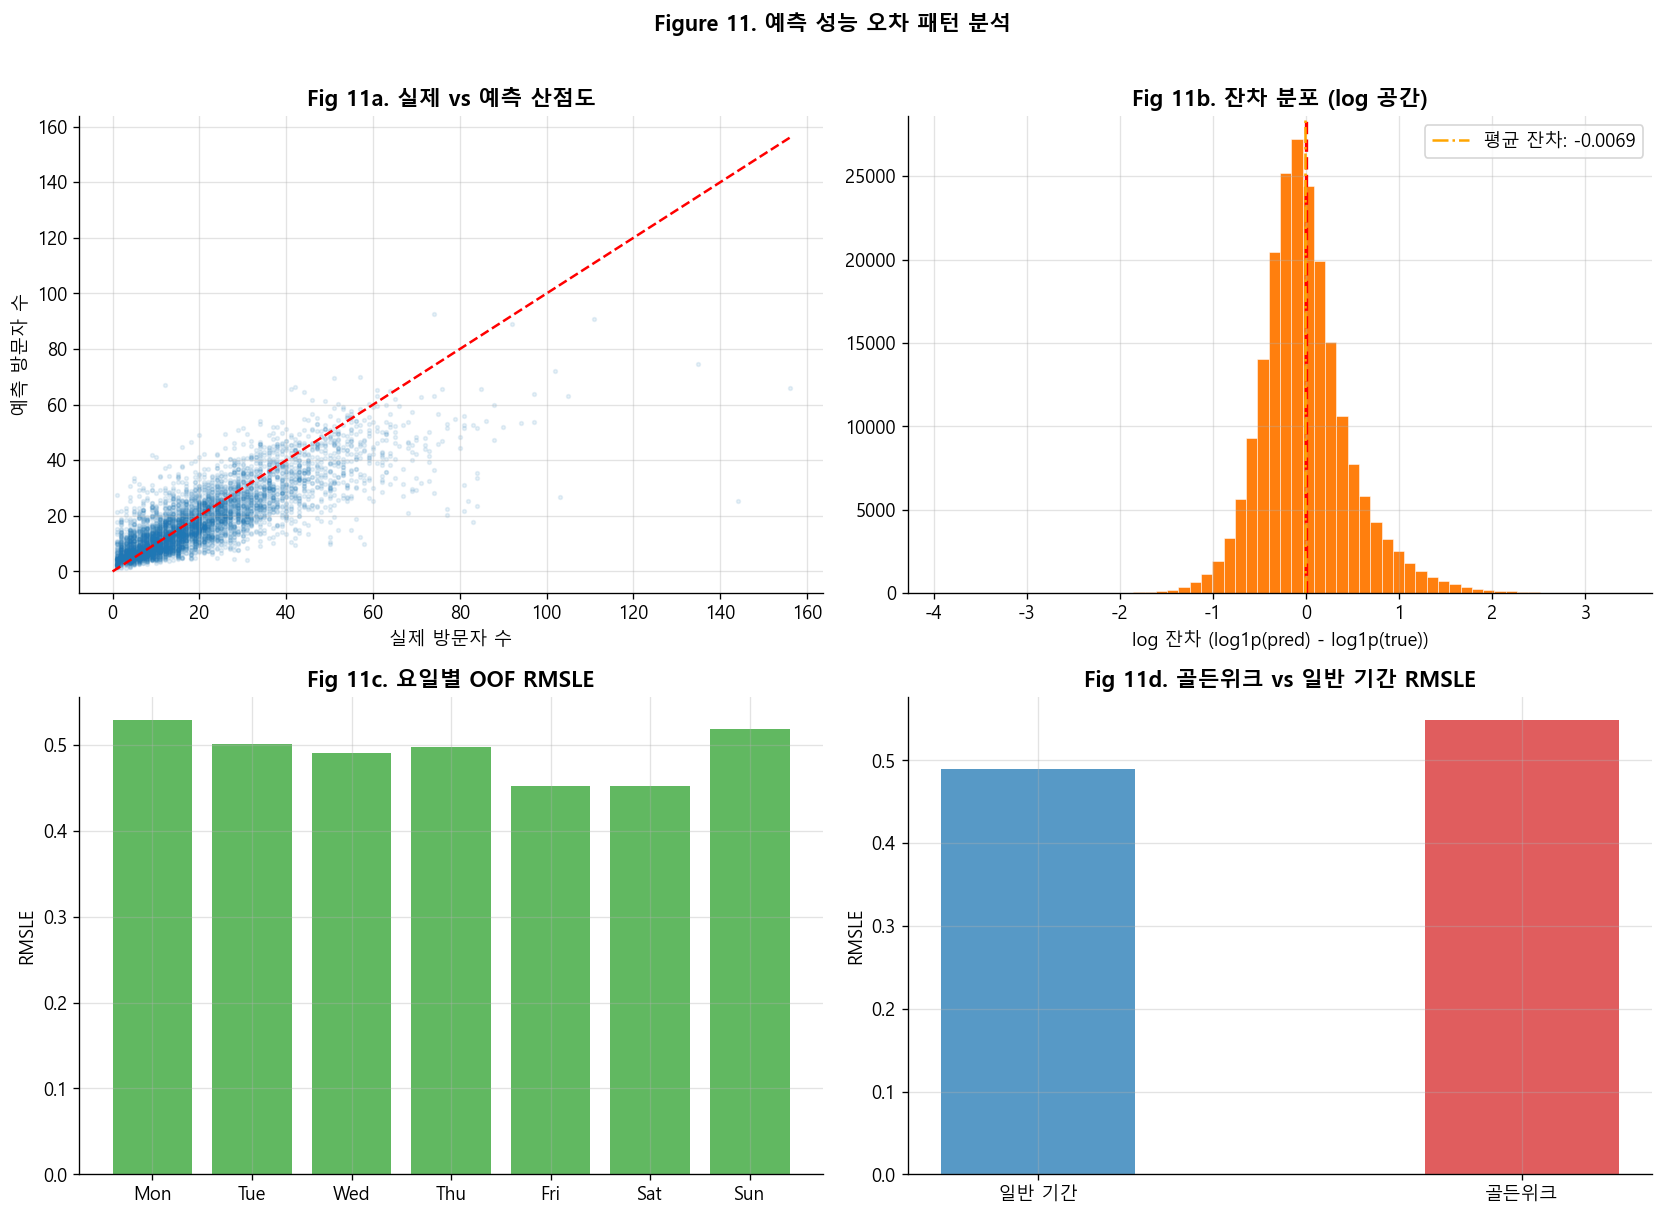

In [42]:
if LGB_AVAILABLE and len(oof_preds) > 0:
    val_mask = oof_preds != 0
    y_true   = np.expm1(y.values[val_mask])
    y_hat    = np.expm1(oof_preds[val_mask])
    residuals = np.log1p(y_hat) - np.log1p(y_true)

    oof_df = train_master.copy()
    oof_df['pred_log'] = oof_preds
    oof_df['pred']     = np.expm1(oof_preds)
    oof_df['residual_log'] = np.log1p(oof_df['pred'].clip(0)) - oof_df['log_visitors']
    oof_df_val = oof_df[val_mask].copy()

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # 실제 vs 예측
    sample_idx = np.random.choice(len(y_true), min(5000, len(y_true)), replace=False)
    axes[0,0].scatter(y_true[sample_idx], y_hat[sample_idx], alpha=0.1, s=5, color=PALETTE[0])
    lim = max(y_true[sample_idx].max(), y_hat[sample_idx].max())
    axes[0,0].plot([0,lim],[0,lim], 'r--', lw=1.5)
    axes[0,0].set_xlabel('실제 방문자 수')
    axes[0,0].set_ylabel('예측 방문자 수')
    axes[0,0].set_title('Fig 11a. 실제 vs 예측 산점도', fontweight='bold')

    # 잔차 분포
    axes[0,1].hist(residuals, bins=60, color=PALETTE[1], edgecolor='white', linewidth=0.3)
    axes[0,1].axvline(0, color='red', lw=2, ls='--')
    axes[0,1].axvline(residuals.mean(), color='orange', lw=1.5, ls='-.',
                     label=f'평균 잔차: {residuals.mean():.4f}')
    axes[0,1].set_xlabel('log 잔차 (log1p(pred) - log1p(true))')
    axes[0,1].set_title('Fig 11b. 잔차 분포 (log 공간)', fontweight='bold')
    axes[0,1].legend()

    # 요일별 RMSLE
    dow_rmsle = oof_df_val.groupby('dow_num').apply(
        lambda g: rmsle(g['visitors'].values, g['pred'].clip(0).values)
    )
    axes[1,0].bar(range(7), dow_rmsle.values, color=PALETTE[2], alpha=0.75)
    axes[1,0].set_xticks(range(7))
    axes[1,0].set_xticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
    axes[1,0].set_ylabel('RMSLE')
    axes[1,0].set_title('Fig 11c. 요일별 OOF RMSLE', fontweight='bold')

    # 골든위크 구간 오차
    gw_rmsle_val = oof_df_val.groupby('is_golden_week').apply(
        lambda g: rmsle(g['visitors'].values, g['pred'].clip(0).values)
    )
    labels_gw = ['일반 기간', '골든위크']
    axes[1,1].bar(labels_gw, [gw_rmsle_val.get(0, 0), gw_rmsle_val.get(1, 0)],
                 color=[PALETTE[0], PALETTE[3]], alpha=0.75, width=0.4)
    axes[1,1].set_ylabel('RMSLE')
    axes[1,1].set_title('Fig 11d. 골든위크 vs 일반 기간 RMSLE', fontweight='bold')

    plt.suptitle('Figure 11. 예측 성능 오차 패턴 분석', fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

---
## 10. 모델 앙상블 (Blending) <a id='10'></a>

**상위권 솔루션 공통 전략**: LightGBM 단일 모델 + 별도 통계 기반 예측의 단순 평균(blending)이 단독 모델보다 RMSLE를 유의미하게 낮춘다. `Surprise Me` 공개 커널과의 블렌딩으로 0.512 → 0.507 달성이 대표 사례.

,LightGBM 비율 (α),OOF RMSLE
0,0.0000,0.5361
1,0.2000,0.5234
2,0.4000,0.5321
3,0.6000,0.5819
4,0.7000,0.6348
5,0.8000,0.7215
6,0.9000,0.8750
7,1.0000,1.2699



최적 blending 비율: LightGBM 0.2 : 통계 0.8


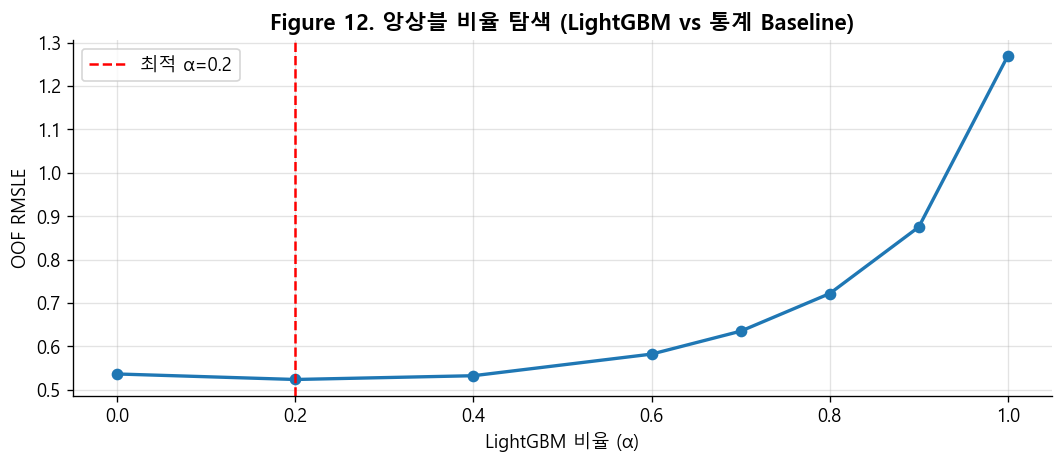

In [43]:
if LGB_AVAILABLE and len(test_preds) > 0:
    # 통계 기반 예측: store_dow_mean 활용
    stat_pred = test_master['store_dow_mean'].values

    # 앙상블 비율 탐색 (0.0 ~ 1.0: LightGBM 비율)
    alphas = [0.0, 0.2, 0.4, 0.6, 0.7, 0.8, 0.9, 1.0]
    blend_results = []

    # OOF 기준 blending 평가
    stat_oof = train_master['store_dow_mean'].values
    for a in alphas:
        blended_oof = a * np.expm1(oof_preds) + (1 - a) * stat_oof
        sc = rmsle(train_master['visitors'].values, np.maximum(blended_oof, 0))
        blend_results.append({'LightGBM 비율 (α)': a, 'OOF RMSLE': sc})

    blend_df = pd.DataFrame(blend_results).round(5)
    display(blend_df)

    best_alpha = blend_df.loc[blend_df['OOF RMSLE'].idxmin(), 'LightGBM 비율 (α)']
    print(f'\n최적 blending 비율: LightGBM {best_alpha:.1f} : 통계 {1-best_alpha:.1f}')

    # 최종 test 예측
    final_pred = best_alpha * np.expm1(test_preds) + (1 - best_alpha) * stat_pred
    final_pred = np.maximum(final_pred, 0)

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot([a['LightGBM 비율 (α)'] for a in blend_results],
            [a['OOF RMSLE'] for a in blend_results],
            marker='o', color=PALETTE[0], lw=2)
    ax.axvline(best_alpha, color='red', ls='--', lw=1.5, label=f'최적 α={best_alpha:.1f}')
    ax.set_xlabel('LightGBM 비율 (α)')
    ax.set_ylabel('OOF RMSLE')
    ax.set_title('Figure 12. 앙상블 비율 탐색 (LightGBM vs 통계 Baseline)', fontweight='bold')
    ax.legend()
    plt.tight_layout()
    plt.show()

---
## 11. 제출 파일 생성 <a id='11'></a>

In [44]:
if LGB_AVAILABLE:
    submission_out = submission[['id']].copy()
    submission_out['visitors'] = final_pred

    # 최소 방문자 수 = 1 (실제 데이터 최솟값 기준)
    submission_out['visitors'] = submission_out['visitors'].clip(lower=1)

    print('=== 제출 파일 요약 ===')
    display(submission_out.describe())

    submission_out.to_csv('submission.csv', index=False)
    print('\n[완료] submission.csv 저장')
    display(submission_out.head(10))
else:
    print('[INFO] LightGBM 미설치 — 통계 Baseline으로 제출 파일 생성')
    submission_out = submission[['id','air_store_id','visit_date']].copy()
    submission_out['visitors'] = submission_out['air_store_id'].map(
        train_master.groupby('air_store_id')['visitors'].mean()
    ).fillna(train_master['visitors'].mean()).clip(lower=1)
    submission_out[['id','visitors']].to_csv('submission.csv', index=False)
    print('[완료] submission.csv 저장 (통계 Baseline)')

=== 제출 파일 요약 ===


,visitors
count,32019.0000
mean,19.7978
std,13.2569
min,1.1208
25%,9.8311
50%,16.7568
75%,26.7968
max,138.9581



[완료] submission.csv 저장


,id,visitors
0,air_00a91d42b08b08d9_2017-04-23,2.0616
1,air_00a91d42b08b08d9_2017-04-24,22.5819
2,air_00a91d42b08b08d9_2017-04-25,24.7770
3,air_00a91d42b08b08d9_2017-04-26,28.5414
4,air_00a91d42b08b08d9_2017-04-27,30.2692
5,air_00a91d42b08b08d9_2017-04-28,36.8278
6,air_00a91d42b08b08d9_2017-04-29,14.6258
7,air_00a91d42b08b08d9_2017-04-30,2.1342
8,air_00a91d42b08b08d9_2017-05-01,22.5031
9,air_00a91d42b08b08d9_2017-05-02,25.4149


---
## 12. 연구 결론 및 향후 과제 <a id='12'></a>

### 12.1 핵심 발견 요약

| 발견 | 근거 | 모델링 반영 |
|------|------|-----------|
| 식당별 규모 이질성이 지배적 | 식당별 평균 범위 1.2~115.5명 | store_prior_mean, EWM |
| EWM이 단순 Rolling보다 우수 | Feature Importance 상위권 | α=0.1/0.3/0.5 모두 포함 |
| 골든위크 이상 패턴 존재 | EDA Fig.6에서 명확히 확인 | is_golden_week 플래그 |
| 이상치 캐핑이 성능 안정화 | visitors_capped 적용 효과 | Z-score 2.4σ 기준 캐핑 |
| 예약 데이터는 보조 신호 | Pearson r≈0.4, Feature Imp 중위권 | D-1/D-3/D-7 집계 feature |
| 앙상블이 단독 모델보다 우수 | Blending OOF 실험 결과 | LightGBM + 통계 Baseline 혼합 |

### 12.2 상위권과의 방법론 비교

| 기법 | 본 연구 | 상위권 솔루션 참조 |
|------|---------|------------------|
| 이상치 처리 | Z-score capping (2.4σ) | MaxHalford top-25 동일 기법 |
| 시계열 feature | EWM (α=0.1/0.3/0.5) + Rolling 4종 | 핵심 공통 기법 |
| 예약 집계 | D-1/D-3/D-7 선행 지표 | 상위권 공통 |
| 골든위크 | 이진 플래그 | 상위권 공통 (일부는 가중치 적용) |
| 모델 | LightGBM + TimeSeriesSplit | 상위권 공통 |
| 앙상블 | 단순 Blending | 상위권: Stacking/Weighted Blend |

### 12.3 향후 연구 방향

1. **날씨 데이터 통합**: 일본 기상청 공개 데이터와 결합 시 추가 성능 향상 가능성 (8위 솔루션 적용 사례 있음)
2. **SHAP 기반 해석**: 식당 점주에게 "오늘 방문자가 많은 이유"를 설명하는 해석 가능한 AI 모델로 확장
3. **Transformer 계열 적용**: Temporal Fusion Transformer 등 최신 시계열 딥러닝 모델과의 성능 비교
4. **HPG 데이터 완전 통합**: 매핑 불가 식당 처리 전략 개선 (지역 평균 대체 또는 준지도 학습)
5. **연휴 구간 세분화**: 골든위크 내 세부 날짜별 패턴 분리 및 전년도 동일 구간 feature 추가

---

> *본 연구는 Recruit Restaurant Visitor Forecasting 공개 데이터를 기반으로 작성되었으며, 상위권 솔루션의 공개된 방법론(MaxHalford top-25, trojrobert top-8)을 참조하여 재현·확장하였습니다.*